# setM Basin Enrichment Matching Phylo Test

This notebook compares species using **setM basin-relative MoSeq enrichment profiles**, without assuming that arm labels are shared across species.

For each species and setM basin, it computes:

```text
E(species, basin, syllable) = log2(p(syllable | basin, species) / p(syllable | species))
```

Each species is treated as an unordered set of four basin enrichment vectors. For each species pair, the notebook computes all basin-to-basin enrichment distances, uses Hungarian matching to find the lowest-cost basin alignment, and clusters species from the resulting matched species distances.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import squareform

REPO_ROOT = Path('/Users/meganbishop/slowmodeevo')
TUNING_REPRESENTATION = 'egocentered_and_normalized_distances'
SETM_ROOT = REPO_ROOT / 'outputs' / 'single_species_distance_comparison' / 'tuning' / TUNING_REPRESENTATION
SETM_DENSITY_FILE = 'moseq_density_by_nested_arm_global_arms.csv'
OUT_DIR = SETM_ROOT / 'setM_basin_syllable_matching_phylo'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-12
REFERENCE_SPECIES = 'Peromyscus_polionotus'
ENRICHMENT_METRICS = ('correlation', 'euclidean')


## Load setM basin syllable counts

The saved `moseq_density_by_nested_arm_global_arms.csv` tables contain soft arm-weighted MoSeq counts. For enrichment, we keep the counts, normalize each arm to `p(syllable | arm, species)`, and normalize all arms pooled within a species to `p(syllable | species)`.


In [3]:
def load_species_setm_count_matrix(species_dir):
    path = species_dir / 'fly_style_plot_recreations' / SETM_DENSITY_FILE
    if not path.exists():
        return None, path, None
    df = pd.read_csv(path)
    required = {'arm', 'moseq_cluster', 'weighted_frames'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'{path} is missing columns: {sorted(missing)}')
    matrix = (
        df.pivot_table(
            index='arm',
            columns='moseq_cluster',
            values='weighted_frames',
            aggfunc='sum',
            fill_value=0.0,
        )
        .astype(float)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    label_columns = [
        column for column in ['moseq_label', 'moseq_syllable_name', 'moseq_category']
        if column in df.columns
    ]
    labels = None
    if label_columns:
        labels = (
            df[['moseq_cluster', *label_columns]]
            .drop_duplicates('moseq_cluster')
            .copy()
        )
        labels['moseq_cluster'] = labels['moseq_cluster'].astype(int)
    return matrix, path, labels


setm_count_matrices = {}
setm_syllable_label_frames = []
inventory_rows = []
for species_dir in sorted(path for path in SETM_ROOT.iterdir() if path.is_dir() and not path.name.startswith('.')):
    matrix, path, labels = load_species_setm_count_matrix(species_dir)
    if matrix is None:
        continue
    setm_count_matrices[species_dir.name] = matrix
    if labels is not None:
        labels = labels.copy()
        labels['species'] = species_dir.name
        setm_syllable_label_frames.append(labels)
    inventory_rows.append({
        'species': species_dir.name,
        'path': str(path),
        'n_arms': int(matrix.shape[0]),
        'n_syllables': int(matrix.shape[1]),
        'weighted_frames': float(matrix.to_numpy().sum()),
    })

if not setm_count_matrices:
    raise FileNotFoundError(f'No {SETM_DENSITY_FILE} files found under {SETM_ROOT}')

all_syllables = sorted(set().union(*[set(matrix.columns) for matrix in setm_count_matrices.values()]))
for species, matrix in list(setm_count_matrices.items()):
    setm_count_matrices[species] = matrix.reindex(columns=all_syllables, fill_value=0.0)

if setm_syllable_label_frames:
    syllable_labels_raw = pd.concat(setm_syllable_label_frames, ignore_index=True)
else:
    syllable_labels_raw = pd.DataFrame({'moseq_cluster': all_syllables})

syllable_label_rows = []
for syllable in all_syllables:
    sub = syllable_labels_raw[syllable_labels_raw['moseq_cluster'].astype(int) == int(syllable)]
    row = {'moseq_cluster': int(syllable)}
    for column in ['moseq_label', 'moseq_syllable_name', 'moseq_category']:
        if column in sub.columns and sub[column].notna().any():
            row[column] = sub[column].dropna().astype(str).mode().iloc[0]
        else:
            row[column] = None
    row['syllable_label'] = row.get('moseq_label') or (
        f'{int(syllable)}: {row.get("moseq_syllable_name")}'
        if row.get('moseq_syllable_name') else str(int(syllable))
    )
    syllable_label_rows.append(row)

syllable_label_df = pd.DataFrame(syllable_label_rows).sort_values('moseq_cluster')
syllable_label_map = dict(zip(syllable_label_df['moseq_cluster'], syllable_label_df['syllable_label']))
syllable_name_map = dict(zip(syllable_label_df['moseq_cluster'], syllable_label_df['moseq_syllable_name']))
syllable_category_map = dict(zip(syllable_label_df['moseq_cluster'], syllable_label_df['moseq_category']))
syllable_label_path = OUT_DIR / 'setM_moseq_syllable_labels.csv'
syllable_label_df.to_csv(syllable_label_path, index=False)

setm_inventory = pd.DataFrame(inventory_rows).sort_values('species')
setm_inventory.to_csv(OUT_DIR / 'setM_basin_syllable_count_matrix_inventory.csv', index=False)
display(setm_inventory)
display(syllable_label_df.head(50))
display({species: matrix.shape for species, matrix in setm_count_matrices.items()})
print('wrote', syllable_label_path)

,species,path,n_arms,n_syllables,weighted_frames
0,Mus_caroli,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,9287719.0
1,Mus_musculus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,85748778.0
2,Mus_spretus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,9549539.0
3,Peromyscus_californicus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,5183680.0
4,Peromyscus_gossypinus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,4296823.0
5,Peromyscus_leucopus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,3023824.0
6,Peromyscus_maniculatus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,31749046.0
7,Peromyscus_polionotus,/Users/meganbishop/slowmodeevo/outputs/single_...,4,50,10583119.0


,moseq_cluster,moseq_label,moseq_syllable_name,moseq_category,syllable_label
0,0,0: head_low,None,None,0: head_low
1,1,1: head_down,None,None,1: head_down
2,2,2: sniff_floor,None,None,2: sniff_floor
3,3,3: step_to_stop,None,None,3: step_to_stop
4,4,4: turn_left,None,None,4: turn_left
5,5,5: enter_rear,None,None,5: enter_rear
6,6,6: turn_right,None,None,6: turn_right
7,7,7: extend_rear,None,None,7: extend_rear
8,8,8: extend_rear_2,None,None,8: extend_rear_2
9,9,9: still,None,None,9: still


{'Mus_caroli': (4, 50),
 'Mus_musculus': (4, 50),
 'Mus_spretus': (4, 50),
 'Peromyscus_californicus': (4, 50),
 'Peromyscus_gossypinus': (4, 50),
 'Peromyscus_leucopus': (4, 50),
 'Peromyscus_maniculatus': (4, 50),
 'Peromyscus_polionotus': (4, 50)}

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/setM_moseq_syllable_labels.csv


## Build basin-relative enrichment vectors

Each basin profile is expressed relative to the species' own overall syllable distribution. This removes the plain species-level behavior baseline and asks how behaviors are organized **within slow-mode basins**.


In [4]:
def enrichment_matrix_from_counts(counts):
    counts = counts.astype(float)
    arm_freq = counts.div(counts.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
    species_counts = counts.sum(axis=0)
    species_freq = species_counts / max(species_counts.sum(), EPS)
    enrichment = np.log2((arm_freq + EPS).div(species_freq + EPS, axis=1))
    return enrichment.replace([np.inf, -np.inf], 0.0).fillna(0.0)


setm_enrichment_matrices = {
    species: enrichment_matrix_from_counts(counts)
    for species, counts in setm_count_matrices.items()
}

for species, matrix in setm_enrichment_matrices.items():
    matrix.to_csv(OUT_DIR / f'{species}_setM_basin_relative_syllable_enrichment.csv')

display({species: matrix.shape for species, matrix in setm_enrichment_matrices.items()})


{'Mus_caroli': (4, 50),
 'Mus_musculus': (4, 50),
 'Mus_spretus': (4, 50),
 'Peromyscus_californicus': (4, 50),
 'Peromyscus_gossypinus': (4, 50),
 'Peromyscus_leucopus': (4, 50),
 'Peromyscus_maniculatus': (4, 50),
 'Peromyscus_polionotus': (4, 50)}

## Compare species by optimal enrichment-basin matching

For a species pair, the basin cost matrix compares every enrichment vector in species A to every enrichment vector in species B. Hungarian assignment finds the minimum-cost one-to-one basin matching. The species distance is the mean distance across the four matched basins.


In [5]:
def vector_distance(a, b, metric='correlation'):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0)
    if metric == 'euclidean':
        return float(np.linalg.norm(a - b))
    if metric == 'correlation':
        a_centered = a - a.mean()
        b_centered = b - b.mean()
        denom = np.linalg.norm(a_centered) * np.linalg.norm(b_centered)
        if denom <= 0 or not np.isfinite(denom):
            return 0.0 if np.allclose(a, b) else 1.0
        return float(1.0 - np.dot(a_centered, b_centered) / denom)
    raise ValueError(f'Unknown enrichment metric: {metric}')


def enrichment_basin_cost_matrix(species_a_matrix, species_b_matrix, metric='correlation'):
    costs = np.zeros((species_a_matrix.shape[0], species_b_matrix.shape[0]), dtype=float)
    for i in range(species_a_matrix.shape[0]):
        for j in range(species_b_matrix.shape[0]):
            costs[i, j] = vector_distance(
                species_a_matrix.iloc[i].to_numpy(dtype=float),
                species_b_matrix.iloc[j].to_numpy(dtype=float),
                metric=metric,
            )
    return costs


def matched_enrichment_species_distance(species_a_matrix, species_b_matrix, metric='correlation'):
    costs = enrichment_basin_cost_matrix(species_a_matrix, species_b_matrix, metric=metric)
    row_ind, col_ind = linear_sum_assignment(costs)
    matched_costs = costs[row_ind, col_ind]
    return {
        'distance': float(matched_costs.mean()),
        'total_cost': float(matched_costs.sum()),
        'rows': row_ind,
        'cols': col_ind,
        'matched_costs': matched_costs,
        'cost_matrix': costs,
    }


enrichment_species_order = sorted(setm_enrichment_matrices)
enrichment_species_distance_matrices = {}
enrichment_matching_rows = []
for metric in ENRICHMENT_METRICS:
    distance_values = np.zeros((len(enrichment_species_order), len(enrichment_species_order)), dtype=float)
    for i, species_a in enumerate(enrichment_species_order):
        for j, species_b in enumerate(enrichment_species_order):
            if j <= i:
                continue
            result = matched_enrichment_species_distance(
                setm_enrichment_matrices[species_a],
                setm_enrichment_matrices[species_b],
                metric=metric,
            )
            distance_values[i, j] = distance_values[j, i] = result['distance']
            arms_a = list(setm_enrichment_matrices[species_a].index)
            arms_b = list(setm_enrichment_matrices[species_b].index)
            for row, col, cost in zip(result['rows'], result['cols'], result['matched_costs']):
                enrichment_matching_rows.append({
                    'metric': metric,
                    'species_a': species_a,
                    'species_b': species_b,
                    'arm_a': int(arms_a[row]),
                    'arm_b': int(arms_b[col]),
                    'basin_distance': float(cost),
                })
    dist_df = pd.DataFrame(distance_values, index=enrichment_species_order, columns=enrichment_species_order)
    enrichment_species_distance_matrices[metric] = dist_df
    dist_df.to_csv(OUT_DIR / f'setM_matched_basin_enrichment_species_{metric}_distance.csv')

enrichment_matching_df = pd.DataFrame(enrichment_matching_rows)
enrichment_matching_df.to_csv(OUT_DIR / 'setM_pairwise_optimal_basin_enrichment_matches.csv', index=False)
display(enrichment_matching_df.head(20))
display({metric: matrix.round(3) for metric, matrix in enrichment_species_distance_matrices.items()})


,metric,species_a,species_b,arm_a,arm_b,basin_distance
0,correlation,Mus_caroli,Mus_musculus,0,0,0.403378
1,correlation,Mus_caroli,Mus_musculus,1,2,0.345948
2,correlation,Mus_caroli,Mus_musculus,2,3,0.242738
3,correlation,Mus_caroli,Mus_musculus,3,1,0.028730
4,correlation,Mus_caroli,Mus_spretus,0,0,0.395063
5,correlation,Mus_caroli,Mus_spretus,1,1,0.383505
6,correlation,Mus_caroli,Mus_spretus,2,2,1.105231
7,correlation,Mus_caroli,Mus_spretus,3,3,0.255545
8,correlation,Mus_caroli,Peromyscus_californicus,0,0,0.366658
9,correlation,Mus_caroli,Peromyscus_californicus,1,1,0.202668


{'correlation':                          Mus_caroli  Mus_musculus  Mus_spretus  \
 Mus_caroli                    0.000         0.255        0.535   
 Mus_musculus                  0.255         0.000        0.413   
 Mus_spretus                   0.535         0.413        0.000   
 Peromyscus_californicus       0.562         0.440        0.347   
 Peromyscus_gossypinus         0.495         0.428        0.321   
 Peromyscus_leucopus           0.579         0.540        0.379   
 Peromyscus_maniculatus        0.554         0.412        0.296   
 Peromyscus_polionotus         0.527         0.408        0.273   
 
                          Peromyscus_californicus  Peromyscus_gossypinus  \
 Mus_caroli                                 0.562                  0.495   
 Mus_musculus                               0.440                  0.428   
 Mus_spretus                                0.347                  0.321   
 Peromyscus_californicus                    0.000                  0.091   


## Species trees from matched enrichment distances


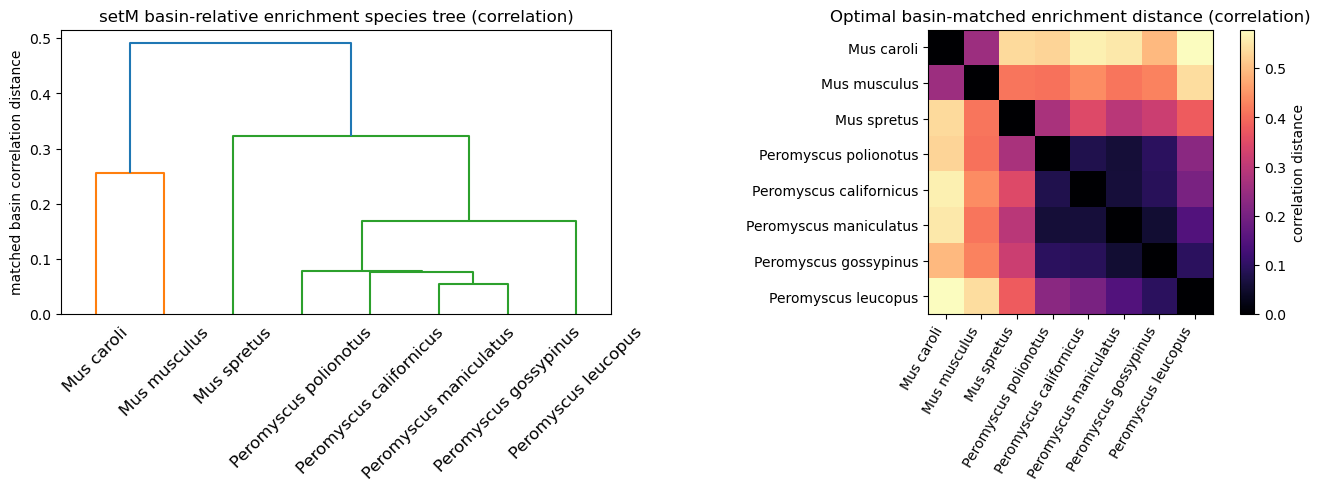

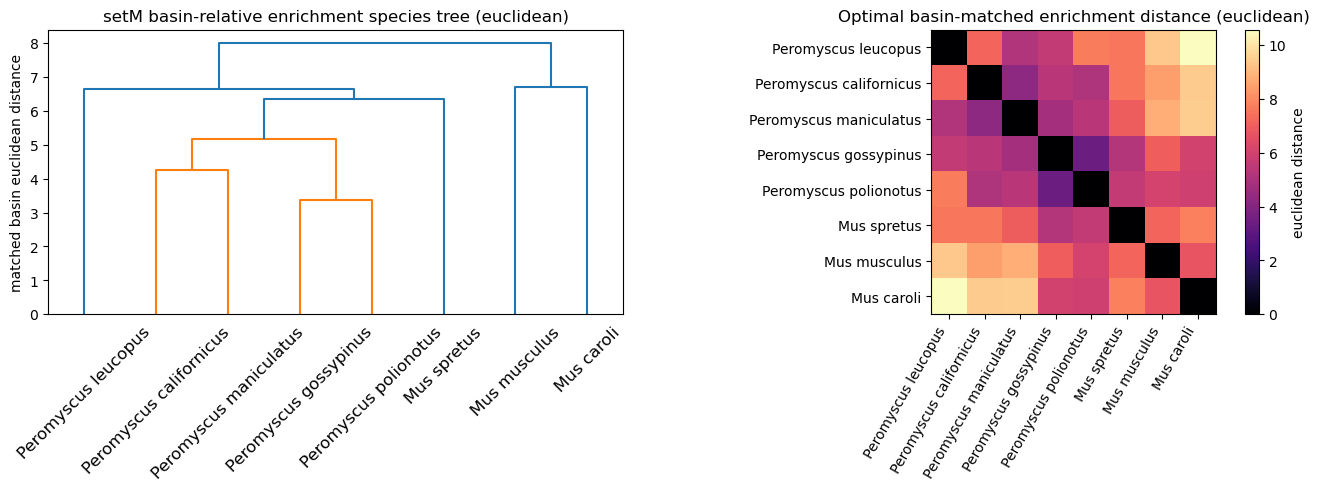

In [6]:
for metric, dist_df in enrichment_species_distance_matrices.items():
    condensed = squareform(dist_df.to_numpy(dtype=float), checks=False)
    tree = linkage(condensed, method='average', optimal_ordering=True)
    leaf_order = dist_df.index[leaves_list(tree)]
    ordered = dist_df.loc[leaf_order, leaf_order]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
    dendrogram(
        tree,
        labels=[label.replace('_', ' ') for label in dist_df.index],
        leaf_rotation=45,
        ax=axes[0],
    )
    axes[0].set_title(f'setM basin-relative enrichment species tree ({metric})')
    axes[0].set_ylabel(f'matched basin {metric} distance')

    im = axes[1].imshow(ordered.to_numpy(), cmap='magma')
    axes[1].set_xticks(np.arange(len(ordered)))
    axes[1].set_yticks(np.arange(len(ordered)))
    axes[1].set_xticklabels([label.replace('_', ' ') for label in ordered.columns], rotation=60, ha='right')
    axes[1].set_yticklabels([label.replace('_', ' ') for label in ordered.index])
    axes[1].set_title(f'Optimal basin-matched enrichment distance ({metric})')
    fig.colorbar(im, ax=axes[1], label=f'{metric} distance')
    plt.show()


## No-matching enrichment control

This control keeps setM arm labels fixed and compares same-index arms only, then averages over arms. It asks how much the species tree depends on allowing basins to be relabeled.


,metric,mean_optimal_matched_distance,mean_same_index_control_distance,pearson_r_between_distance_matrices
0,correlation,0.317253,0.364229,0.803559
1,euclidean,6.776345,7.498941,0.872371


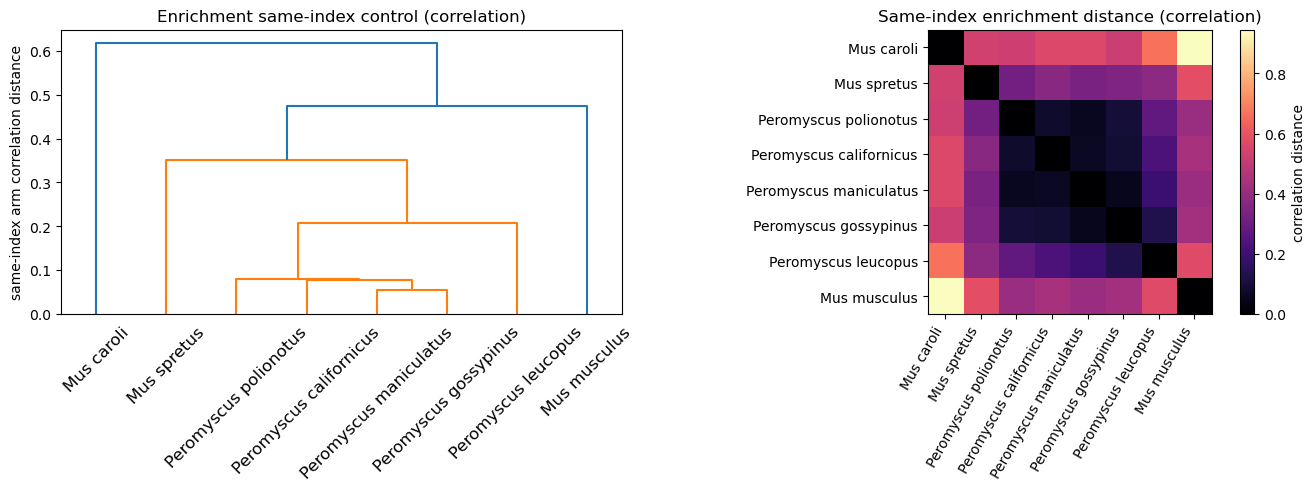

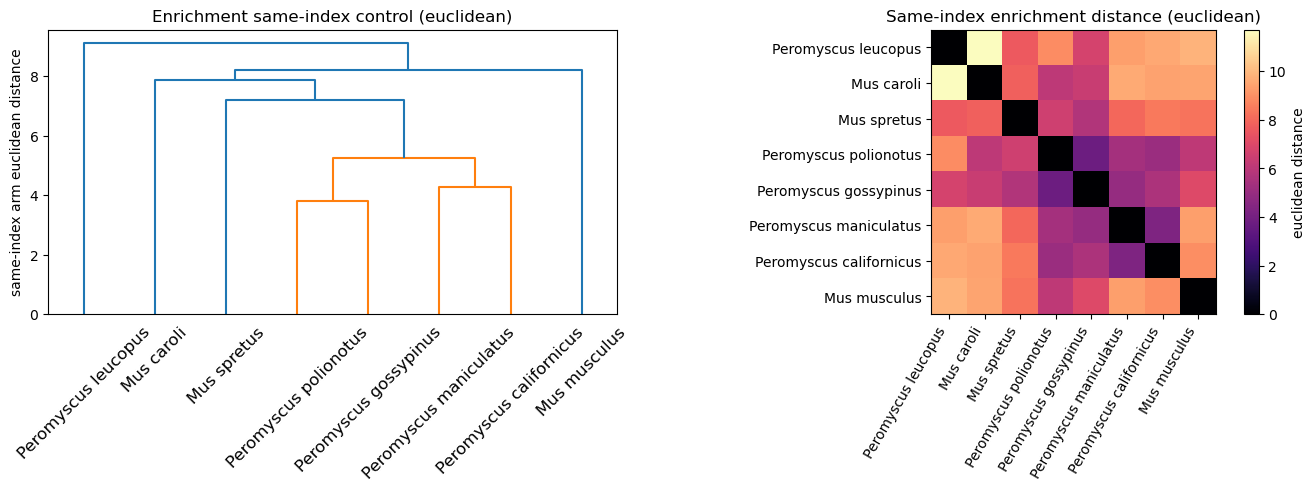

In [7]:
def same_index_enrichment_species_distance(species_a_matrix, species_b_matrix, metric='correlation'):
    common_arms = sorted(set(species_a_matrix.index) & set(species_b_matrix.index))
    if not common_arms:
        raise ValueError('No common arm labels available for same-index control')
    costs = [
        vector_distance(
            species_a_matrix.loc[arm].to_numpy(dtype=float),
            species_b_matrix.loc[arm].to_numpy(dtype=float),
            metric=metric,
        )
        for arm in common_arms
    ]
    return float(np.mean(costs))


same_index_enrichment_distance_matrices = {}
for metric in ENRICHMENT_METRICS:
    values = np.zeros((len(enrichment_species_order), len(enrichment_species_order)), dtype=float)
    for i, species_a in enumerate(enrichment_species_order):
        for j, species_b in enumerate(enrichment_species_order):
            if j <= i:
                continue
            values[i, j] = values[j, i] = same_index_enrichment_species_distance(
                setm_enrichment_matrices[species_a],
                setm_enrichment_matrices[species_b],
                metric=metric,
            )
    dist_df = pd.DataFrame(values, index=enrichment_species_order, columns=enrichment_species_order)
    same_index_enrichment_distance_matrices[metric] = dist_df
    dist_df.to_csv(OUT_DIR / f'setM_enrichment_{metric}_same_index_distance.csv')

control_summary_rows = []
for metric, matched_df in enrichment_species_distance_matrices.items():
    control_df = same_index_enrichment_distance_matrices[metric]
    iu = np.triu_indices_from(matched_df.to_numpy(), k=1)
    matched_values = matched_df.to_numpy()[iu]
    control_values = control_df.loc[matched_df.index, matched_df.columns].to_numpy()[iu]
    control_summary_rows.append({
        'metric': metric,
        'mean_optimal_matched_distance': float(np.mean(matched_values)),
        'mean_same_index_control_distance': float(np.mean(control_values)),
        'pearson_r_between_distance_matrices': float(np.corrcoef(matched_values, control_values)[0, 1]),
    })
control_summary = pd.DataFrame(control_summary_rows)
control_summary.to_csv(OUT_DIR / 'setM_enrichment_optimal_matching_vs_same_index_control_summary.csv', index=False)
display(control_summary)

for metric, dist_df in same_index_enrichment_distance_matrices.items():
    condensed = squareform(dist_df.to_numpy(dtype=float), checks=False)
    tree = linkage(condensed, method='average', optimal_ordering=True)
    leaf_order = dist_df.index[leaves_list(tree)]
    ordered = dist_df.loc[leaf_order, leaf_order]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
    dendrogram(
        tree,
        labels=[label.replace('_', ' ') for label in dist_df.index],
        leaf_rotation=45,
        ax=axes[0],
    )
    axes[0].set_title(f'Enrichment same-index control ({metric})')
    axes[0].set_ylabel(f'same-index arm {metric} distance')

    im = axes[1].imshow(ordered.to_numpy(), cmap='magma')
    axes[1].set_xticks(np.arange(len(ordered)))
    axes[1].set_yticks(np.arange(len(ordered)))
    axes[1].set_xticklabels([label.replace('_', ' ') for label in ordered.columns], rotation=60, ha='right')
    axes[1].set_yticklabels([label.replace('_', ' ') for label in ordered.index])
    axes[1].set_title(f'Same-index enrichment distance ({metric})')
    fig.colorbar(im, ax=axes[1], label=f'{metric} distance')
    plt.show()


## Optional reference-species arm matching

This table makes the optimal enrichment assignment visible by showing how each species' setM basins match to the reference species' basins.


In [8]:
if REFERENCE_SPECIES in setm_enrichment_matrices:
    reference_rows = []
    ref_matrix = setm_enrichment_matrices[REFERENCE_SPECIES]
    for metric in ENRICHMENT_METRICS:
        for species in enrichment_species_order:
            if species == REFERENCE_SPECIES:
                continue
            result = matched_enrichment_species_distance(ref_matrix, setm_enrichment_matrices[species], metric=metric)
            ref_arms = list(ref_matrix.index)
            species_arms = list(setm_enrichment_matrices[species].index)
            for row, col, cost in zip(result['rows'], result['cols'], result['matched_costs']):
                reference_rows.append({
                    'metric': metric,
                    'reference_species': REFERENCE_SPECIES,
                    'species': species,
                    'reference_arm': int(ref_arms[row]),
                    'matched_species_arm': int(species_arms[col]),
                    'basin_distance': float(cost),
                })
    reference_matching_df = pd.DataFrame(reference_rows)
    reference_matching_df.to_csv(OUT_DIR / f'setM_enrichment_reference_matches_to_{REFERENCE_SPECIES}.csv', index=False)
    display(reference_matching_df)
else:
    print(f'REFERENCE_SPECIES={REFERENCE_SPECIES!r} was not found in the loaded species matrices.')


,metric,reference_species,species,reference_arm,matched_species_arm,basin_distance
0,correlation,Peromyscus_polionotus,Mus_caroli,0,0,0.299561
1,correlation,Peromyscus_polionotus,Mus_caroli,1,1,0.220985
2,correlation,Peromyscus_polionotus,Mus_caroli,2,2,1.511407
3,correlation,Peromyscus_polionotus,Mus_caroli,3,3,0.076236
4,correlation,Peromyscus_polionotus,Mus_musculus,0,0,0.060170
5,correlation,Peromyscus_polionotus,Mus_musculus,1,1,0.026910
6,correlation,Peromyscus_polionotus,Mus_musculus,2,2,0.137500
7,correlation,Peromyscus_polionotus,Mus_musculus,3,3,1.408072
8,correlation,Peromyscus_polionotus,Mus_spretus,0,0,0.304136
9,correlation,Peromyscus_polionotus,Mus_spretus,1,2,0.460180


## Reference-aligned slow-mode coordinates

The next plots need a shared coordinate system. Because setM arm labels are not guaranteed to match across species, we align each species' four setM arms to `REFERENCE_SPECIES` using the enrichment-vector optimal matching above. This is still an inferred alignment, not a biological guarantee, but it is a useful exploratory coordinate system for asking whether slow-mode dynamics carry phylogenetic structure.


In [9]:
SLOWMODE_FS = 120.0
SLOWMODE_VELOCITY_LAG_SECONDS = 1
SLOWMODE_VELOCITY_LAG_FRAMES = max(1, int(round(SLOWMODE_VELOCITY_LAG_SECONDS * SLOWMODE_FS)))
SLOWMODE_RANDOM_SEED = 14
SLOWMODE_RNG = np.random.default_rng(SLOWMODE_RANDOM_SEED)
SLOWMODE_PCA_FRAMES_PER_SPECIES = 12000
SLOWMODE_VELOCITY_PAIRS_PER_SPECIES = 10000
SLOWMODE_STATS_FRAMES_PER_SPECIES = 60000
SLOWMODE_VECTOR_FIELD_BINS = 18
SLOWMODE_MIN_BIN_COUNT = 20


def _setm_arm_path(species):
    species_dir = SETM_ROOT / species
    preferred = species_dir / f'{species}_arms_setM.npz'
    if preferred.exists():
        return preferred
    matches = sorted(species_dir.glob('*_arms_setM.npz'))
    if not matches:
        raise FileNotFoundError(f'No setM arm file found for {species} under {species_dir}')
    return matches[0]


def load_setm_chi(species):
    with np.load(_setm_arm_path(species), allow_pickle=True) as result:
        chi = np.asarray(result['chi'], dtype=float)
    chi = np.clip(chi, 0.0, None)
    return chi / np.maximum(chi.sum(axis=1, keepdims=True), EPS)


def state_files_for_species(species):
    states_dir = SETM_ROOT / species / 'states'
    return sorted(states_dir.glob('*.npy')) if states_dir.exists() else []


def reference_arm_alignment(species, metric='correlation'):
    if species == REFERENCE_SPECIES:
        arms = list(setm_enrichment_matrices[species].index)
        return {int(arm): int(arm) for arm in arms}
    result = matched_enrichment_species_distance(
        setm_enrichment_matrices[REFERENCE_SPECIES],
        setm_enrichment_matrices[species],
        metric=metric,
    )
    ref_arms = list(setm_enrichment_matrices[REFERENCE_SPECIES].index)
    species_arms = list(setm_enrichment_matrices[species].index)
    return {
        int(ref_arms[row]): int(species_arms[col])
        for row, col in zip(result['rows'], result['cols'])
    }


reference_arm_order = sorted(setm_enrichment_matrices[REFERENCE_SPECIES].index)
species_to_reference_alignment = {
    species: reference_arm_alignment(species, metric='correlation')
    for species in enrichment_species_order
}
alignment_df = pd.DataFrame([
    {'species': species, 'reference_arm': ref_arm, 'species_arm': species_arm}
    for species, mapping in species_to_reference_alignment.items()
    for ref_arm, species_arm in sorted(mapping.items())
])
alignment_df.to_csv(OUT_DIR / f'setM_enrichment_reference_arm_alignment_to_{REFERENCE_SPECIES}.csv', index=False)
display(alignment_df)


def aligned_chi_for_species(species):
    chi = load_setm_chi(species)
    mapping = species_to_reference_alignment[species]
    ordered_species_arms = [mapping[int(ref_arm)] for ref_arm in reference_arm_order]
    return chi[:, ordered_species_arms]


def sampled_states_for_species(species, max_frames, rng):
    samples = []
    chi = aligned_chi_for_species(species)
    remaining = int(max_frames)
    files = state_files_for_species(species)
    if not files:
        raise FileNotFoundError(f'No state files found for {species}')
    per_file = max(1, int(np.ceil(max_frames / len(files))))
    for path in files:
        states = np.asarray(np.load(path, mmap_mode='r')).reshape(-1)
        valid = np.isfinite(states)
        states = states[valid].astype(int, copy=False)
        states = states[(states >= 0) & (states < chi.shape[0])]
        if states.size == 0:
            continue
        take = min(per_file, states.size, remaining)
        if take <= 0:
            break
        idx = rng.choice(states.size, size=take, replace=False)
        samples.append(chi[states[idx]])
        remaining -= take
    if not samples:
        raise RuntimeError(f'No valid states sampled for {species}')
    return np.vstack(samples)


slowmode_sample_by_species = {
    species: sampled_states_for_species(species, SLOWMODE_PCA_FRAMES_PER_SPECIES, SLOWMODE_RNG)
    for species in enrichment_species_order
}
all_slowmode_samples = np.vstack(list(slowmode_sample_by_species.values()))
slowmode_center = all_slowmode_samples.mean(axis=0)
_, _, vh = np.linalg.svd(all_slowmode_samples - slowmode_center, full_matrices=False)
slowmode_pca_components = vh[:2]

explained = np.var((all_slowmode_samples - slowmode_center) @ slowmode_pca_components.T, axis=0)
explained = explained / np.var(all_slowmode_samples - slowmode_center, axis=0).sum()
print('shared aligned-chi PCA variance explained:', explained)


,species,reference_arm,species_arm
0,Mus_caroli,0,0
1,Mus_caroli,1,1
2,Mus_caroli,2,2
3,Mus_caroli,3,3
4,Mus_musculus,0,0
5,Mus_musculus,1,1
6,Mus_musculus,2,2
7,Mus_musculus,3,3
8,Mus_spretus,0,0
9,Mus_spretus,1,2


shared aligned-chi PCA variance explained: [0.86623937 0.09818148]


## Velocity fields and rough potential landscapes

Each species' aligned `chi[states]` trajectory is projected into the shared 2D slow-mode PCA coordinates. The vector field is the average displacement over a short lag, binned over the 2D landscape. The rough potential is `U = -log(density)`, estimated from sampled locations, so low potential means frequently occupied regions.


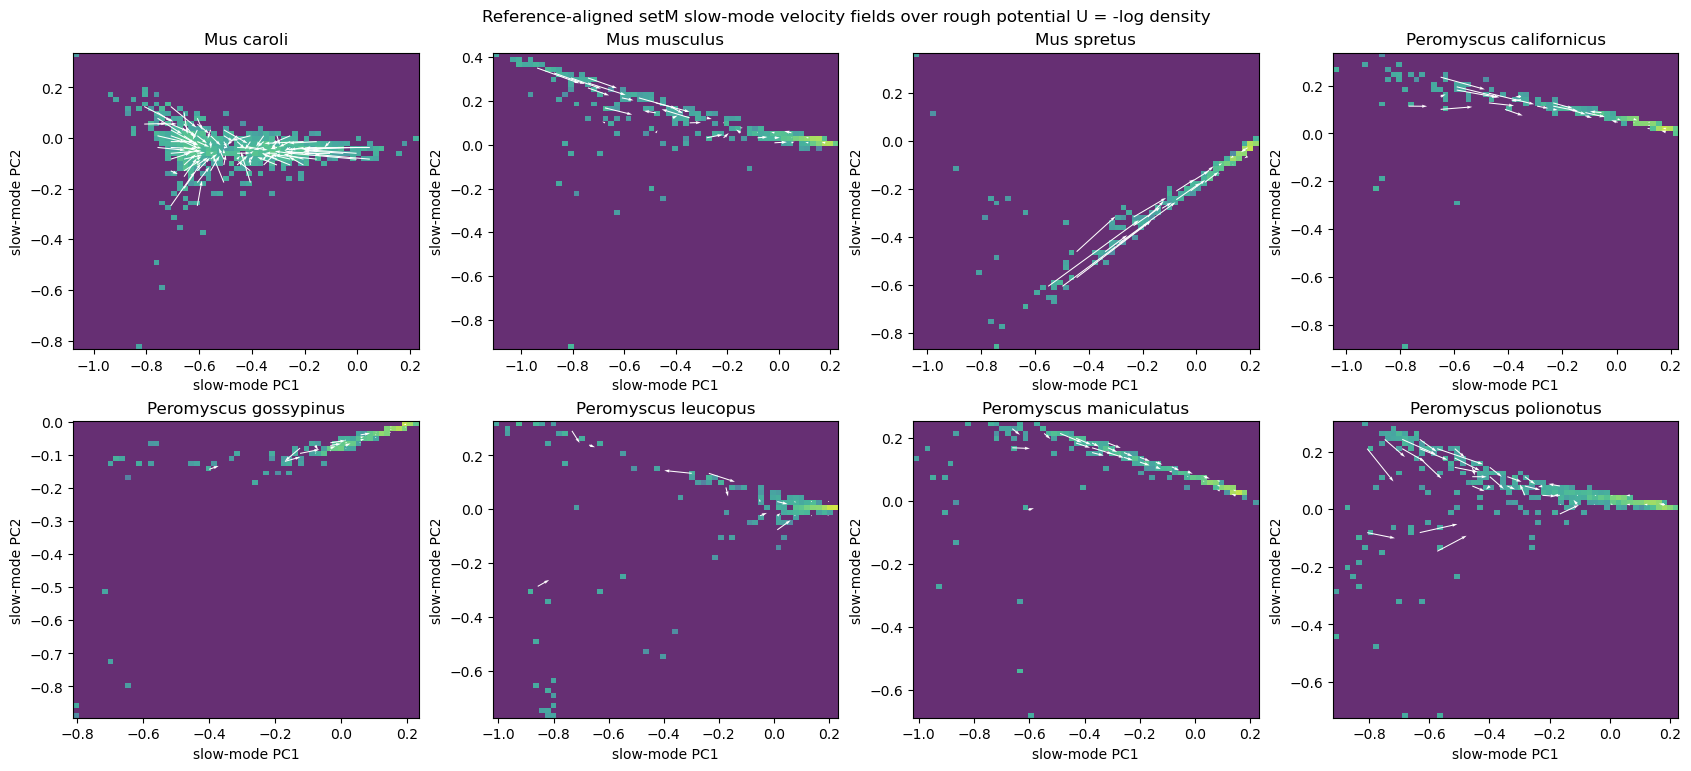

,species,n_velocity_pairs,mean_speed,median_speed,occupied_vector_bins
0,Mus_caroli,10000,0.160840,0.125642,107
1,Mus_musculus,10000,0.081610,0.031310,34
2,Mus_spretus,10000,0.087739,0.028375,22
3,Peromyscus_californicus,10000,0.063941,0.026791,29
4,Peromyscus_gossypinus,10000,0.031159,0.016513,26
5,Peromyscus_leucopus,10000,0.031946,0.011619,17
6,Peromyscus_maniculatus,10000,0.061526,0.027041,30
7,Peromyscus_polionotus,10000,0.092748,0.046551,41


In [10]:
def sample_velocity_pairs(species, max_pairs, lag_frames, rng):
    chi = aligned_chi_for_species(species)
    pair_x = []
    pair_dx = []
    files = state_files_for_species(species)
    per_file = max(1, int(np.ceil(max_pairs / len(files))))
    remaining = int(max_pairs)
    for path in files:
        states = np.asarray(np.load(path, mmap_mode='r')).reshape(-1)
        states = states[np.isfinite(states)].astype(int, copy=False)
        valid = (states >= 0) & (states < chi.shape[0])
        states = states[valid]
        if states.size <= lag_frames:
            continue
        possible = np.arange(0, states.size - lag_frames, dtype=int)
        take = min(per_file, possible.size, remaining)
        if take <= 0:
            break
        starts = rng.choice(possible, size=take, replace=False)
        x0 = chi[states[starts]]
        x1 = chi[states[starts + lag_frames]]
        pair_x.append(x0)
        pair_dx.append(x1 - x0)
        remaining -= take
    if not pair_x:
        raise RuntimeError(f'No velocity pairs sampled for {species}')
    return np.vstack(pair_x), np.vstack(pair_dx)


def project_chi(values):
    return (values - slowmode_center) @ slowmode_pca_components.T


def binned_velocity_field(xy, dxy, bins=18, min_count=20):
    x_edges = np.linspace(np.percentile(xy[:, 0], 1), np.percentile(xy[:, 0], 99), bins + 1)
    y_edges = np.linspace(np.percentile(xy[:, 1], 1), np.percentile(xy[:, 1], 99), bins + 1)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    U = np.full((bins, bins), np.nan)
    V = np.full((bins, bins), np.nan)
    C = np.zeros((bins, bins), dtype=int)
    ix = np.digitize(xy[:, 0], x_edges) - 1
    iy = np.digitize(xy[:, 1], y_edges) - 1
    keep = (ix >= 0) & (ix < bins) & (iy >= 0) & (iy < bins)
    for bx, by, delta in zip(ix[keep], iy[keep], dxy[keep]):
        if np.isnan(U[by, bx]):
            U[by, bx] = 0.0
            V[by, bx] = 0.0
        U[by, bx] += delta[0]
        V[by, bx] += delta[1]
        C[by, bx] += 1
    valid = C >= min_count
    U[valid] = U[valid] / C[valid]
    V[valid] = V[valid] / C[valid]
    U[~valid] = np.nan
    V[~valid] = np.nan
    return x_centers, y_centers, U, V, C


n_species = len(enrichment_species_order)
n_cols = 4
n_rows = int(np.ceil(n_species / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)
velocity_summary_rows = []
for ax, species in zip(axes, enrichment_species_order):
    x0, dx = sample_velocity_pairs(
        species,
        SLOWMODE_VELOCITY_PAIRS_PER_SPECIES,
        SLOWMODE_VELOCITY_LAG_FRAMES,
        SLOWMODE_RNG,
    )
    xy = project_chi(x0)
    dxy = dx @ slowmode_pca_components.T
    hist, x_edges, y_edges = np.histogram2d(xy[:, 0], xy[:, 1], bins=60)
    density = hist.T / max(hist.sum(), 1)
    potential = -np.log(density + 1e-6)
    vmax = np.nanpercentile(potential[np.isfinite(potential)], 95)
    ax.imshow(
        potential,
        origin='lower',
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        cmap='viridis_r',
        alpha=0.82,
        aspect='auto',
        vmin=0,
        vmax=vmax,
    )
    xc, yc, u, v, counts = binned_velocity_field(
        xy,
        dxy,
        bins=SLOWMODE_VECTOR_FIELD_BINS,
        min_count=SLOWMODE_MIN_BIN_COUNT,
    )
    X, Y = np.meshgrid(xc, yc)
    ax.quiver(X, Y, u, v, color='white', angles='xy', scale_units='xy', scale=1.2, width=0.003)
    ax.set_title(species.replace('_', ' '))
    ax.set_xlabel('slow-mode PC1')
    ax.set_ylabel('slow-mode PC2')
    velocity_summary_rows.append({
        'species': species,
        'n_velocity_pairs': int(xy.shape[0]),
        'mean_speed': float(np.linalg.norm(dxy, axis=1).mean()),
        'median_speed': float(np.median(np.linalg.norm(dxy, axis=1))),
        'occupied_vector_bins': int(np.sum(counts >= SLOWMODE_MIN_BIN_COUNT)),
    })
for ax in axes[len(enrichment_species_order):]:
    ax.axis('off')
fig.suptitle('Reference-aligned setM slow-mode velocity fields over rough potential U = -log density')
plt.show()

velocity_summary = pd.DataFrame(velocity_summary_rows)
velocity_summary.to_csv(OUT_DIR / 'setM_aligned_chi_velocity_field_summary.csv', index=False)
display(velocity_summary)


## Within-species fluctuation vs between-species divergence

This plot asks whether the directions animals explore within species are the same directions along which species differ. We compute each species' mean and covariance in reference-aligned `chi` space, eigendecompose the pooled within-species covariance, and then compare within-species variance to between-species divergence along each eigen-direction.


,direction,within_variance,between_species_divergence,ratio_between_to_within,species_score_range
0,1,5.014100e-02,3.774139e-02,7.527051e-01,5.905881e-01
1,2,7.305585e-03,2.562836e-03,3.508050e-01,1.383041e-01
2,3,2.335058e-03,1.185072e-03,5.075129e-01,1.024957e-01
3,4,8.389014e-18,-3.726945e-20,-3.726945e-08,3.008704e-14


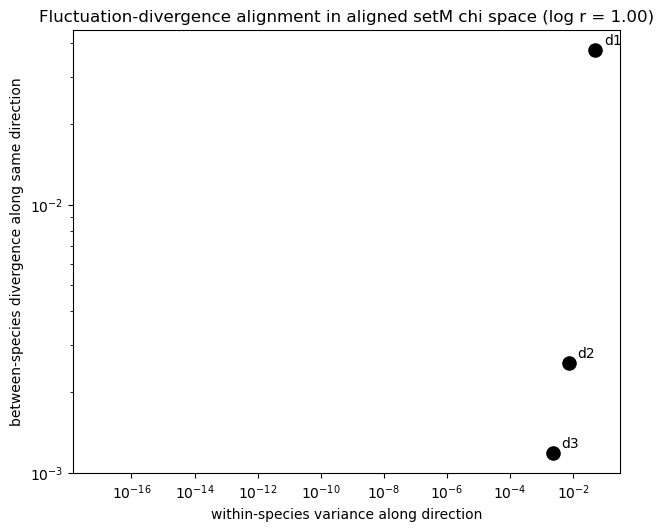

,direction_1,direction_2,direction_3,direction_4
Mus_caroli,-0.117464,-0.150430,-0.220673,0.5
Mus_musculus,-0.596106,-0.247989,-0.224515,0.5
Mus_spretus,-0.698035,-0.126906,-0.223734,0.5
Peromyscus_californicus,-0.645686,-0.248371,-0.216490,0.5
Peromyscus_gossypinus,-0.699431,-0.186702,-0.122019,0.5
Peromyscus_leucopus,-0.708053,-0.215675,-0.198279,0.5
Peromyscus_maniculatus,-0.591672,-0.265210,-0.221151,0.5
Peromyscus_polionotus,-0.546567,-0.240798,-0.205887,0.5


In [11]:
stats_rows = []
species_means = {}
species_covariances = {}
for species in enrichment_species_order:
    sample = sampled_states_for_species(species, SLOWMODE_STATS_FRAMES_PER_SPECIES, SLOWMODE_RNG)
    species_means[species] = sample.mean(axis=0)
    species_covariances[species] = np.cov(sample, rowvar=False)
    stats_rows.append({
        'species': species,
        'n_sampled_frames': int(sample.shape[0]),
    })

mean_matrix = np.vstack([species_means[species] for species in enrichment_species_order])
pooled_within_cov = np.mean([species_covariances[species] for species in enrichment_species_order], axis=0)
grand_mean = mean_matrix.mean(axis=0)
between_cov = np.cov(mean_matrix, rowvar=False)
within_eval, within_evec = np.linalg.eigh(pooled_within_cov)
order = np.argsort(within_eval)[::-1]
within_eval = within_eval[order]
within_evec = within_evec[:, order]

fluctuation_rows = []
for direction in range(within_evec.shape[1]):
    vec = within_evec[:, direction]
    within_variance = float(vec.T @ pooled_within_cov @ vec)
    between_divergence = float(vec.T @ between_cov @ vec)
    species_scores = mean_matrix @ vec
    fluctuation_rows.append({
        'direction': direction + 1,
        'within_variance': within_variance,
        'between_species_divergence': between_divergence,
        'ratio_between_to_within': between_divergence / max(within_variance, EPS),
        'species_score_range': float(species_scores.max() - species_scores.min()),
    })

fluctuation_df = pd.DataFrame(fluctuation_rows)
fluctuation_df.to_csv(OUT_DIR / 'setM_fluctuation_divergence_by_within_species_direction.csv', index=False)
display(fluctuation_df)

r = np.corrcoef(
    np.log10(fluctuation_df['within_variance'] + EPS),
    np.log10(fluctuation_df['between_species_divergence'] + EPS),
)[0, 1]

fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
ax.scatter(
    fluctuation_df['within_variance'],
    fluctuation_df['between_species_divergence'],
    s=90,
    color='black',
)
for _, row in fluctuation_df.iterrows():
    ax.annotate(
        f"d{int(row['direction'])}",
        (row['within_variance'], row['between_species_divergence']),
        textcoords='offset points',
        xytext=(6, 4),
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('within-species variance along direction')
ax.set_ylabel('between-species divergence along same direction')
ax.set_title(f'Fluctuation-divergence alignment in aligned setM chi space (log r = {r:.2f})')
plt.show()

species_score_df = pd.DataFrame(
    mean_matrix @ within_evec,
    index=enrichment_species_order,
    columns=[f'direction_{idx + 1}' for idx in range(within_evec.shape[1])],
)
species_score_df.to_csv(OUT_DIR / 'setM_species_scores_on_within_species_directions.csv')
display(species_score_df)


## Basin-profile table for extra signal visualizations
These summaries reuse the same setM basin-relative enrichment vectors. Each row below is one species-specific basin, with a vector over MoSeq syllables.

In [12]:
BASIN_VIS_METRIC = 'correlation'
BASIN_NETWORK_K_NEIGHBORS = 4

basin_profile_records = []
basin_profile_vectors = []
for species in enrichment_species_order:
    matrix = setm_enrichment_matrices[species]
    for arm in matrix.index:
        basin_profile_records.append({
            'node_id': f'{species}|arm_{int(arm)}',
            'species': species,
            'genus': species.split('_')[0],
            'arm': int(arm),
        })
        basin_profile_vectors.append(matrix.loc[arm].to_numpy(dtype=float))

basin_profile_meta = pd.DataFrame(basin_profile_records)
basin_profile_matrix = np.vstack(basin_profile_vectors)
basin_feature_names = list(next(iter(setm_enrichment_matrices.values())).columns)

basin_profile_df = pd.concat(
    [
        basin_profile_meta,
        pd.DataFrame(basin_profile_matrix, columns=[f'syllable_{name}' for name in basin_feature_names]),
    ],
    axis=1,
)
basin_profile_df.to_csv(OUT_DIR / 'setM_basin_relative_enrichment_profile_table.csv', index=False)
display(basin_profile_meta.head())
print('Basin enrichment profile matrix:', basin_profile_matrix.shape)

,node_id,species,genus,arm
0,Mus_caroli|arm_0,Mus_caroli,Mus,0
1,Mus_caroli|arm_1,Mus_caroli,Mus,1
2,Mus_caroli|arm_2,Mus_caroli,Mus,2
3,Mus_caroli|arm_3,Mus_caroli,Mus,3
4,Mus_musculus|arm_0,Mus_musculus,Mus,0


Basin enrichment profile matrix: (32, 50)


## Idea 5 and 6: per-basin embedding and species clouds
This embeds all species-specific basins in a common enrichment-vector PCA space. Points show individual basins; polygons show each species as a four-basin cloud.

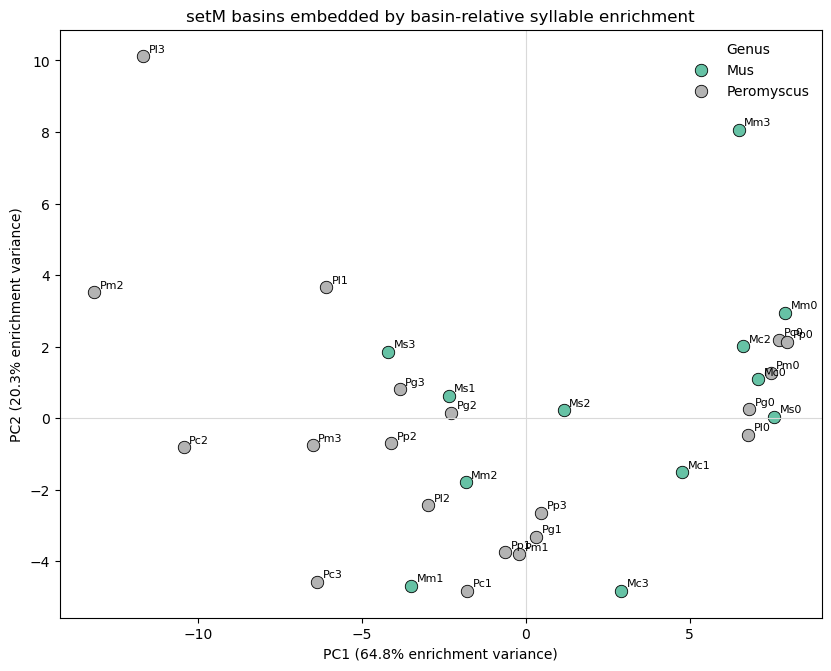

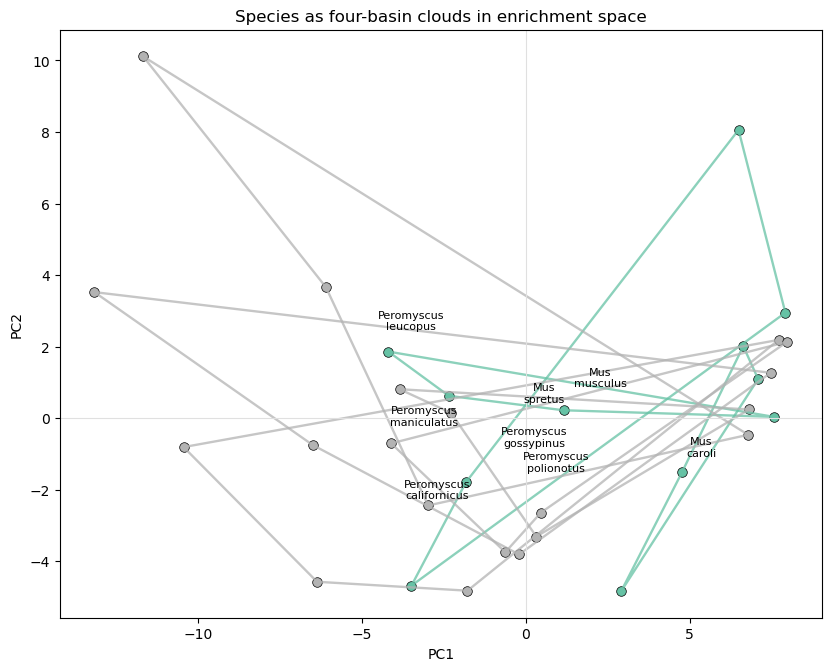

,node_id,species,genus,arm,PC1,PC2
0,Mus_caroli|arm_0,Mus_caroli,Mus,0,7.088156,1.093178
1,Mus_caroli|arm_1,Mus_caroli,Mus,1,4.763251,-1.515915
2,Mus_caroli|arm_2,Mus_caroli,Mus,2,6.634820,2.011827
3,Mus_caroli|arm_3,Mus_caroli,Mus,3,2.911360,-4.833709
4,Mus_musculus|arm_0,Mus_musculus,Mus,0,7.920116,2.947324


In [13]:
def pca_scores(values, n_components=2):
    values = np.asarray(values, dtype=float)
    centered = values - values.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(centered, full_matrices=False)
    scores = centered @ vt[:n_components].T
    variance = (s ** 2) / max(values.shape[0] - 1, 1)
    explained = variance[:n_components] / max(variance.sum(), EPS)
    return scores, explained, vt[:n_components]

basin_pca_scores, basin_pca_explained, basin_pca_components = pca_scores(basin_profile_matrix, n_components=2)
basin_embedding_df = basin_profile_meta.copy()
basin_embedding_df['PC1'] = basin_pca_scores[:, 0]
basin_embedding_df['PC2'] = basin_pca_scores[:, 1]
basin_embedding_df.to_csv(OUT_DIR / 'setM_basin_enrichment_pca_embedding.csv', index=False)

genera = sorted(basin_embedding_df['genus'].unique())
colors = dict(zip(genera, plt.cm.Set2(np.linspace(0, 1, len(genera)))))

fig, ax = plt.subplots(figsize=(8.2, 6.6), constrained_layout=True)
for genus, group in basin_embedding_df.groupby('genus'):
    ax.scatter(group['PC1'], group['PC2'], s=80, label=genus, color=colors[genus], edgecolor='black', linewidth=0.6)
for _, row in basin_embedding_df.iterrows():
    abbrev = ''.join(part[0] for part in row['species'].split('_')[:2])
    ax.annotate(f'{abbrev}{int(row.arm)}', (row.PC1, row.PC2), textcoords='offset points', xytext=(4, 3), fontsize=8)
ax.axhline(0, color='0.85', linewidth=0.8)
ax.axvline(0, color='0.85', linewidth=0.8)
ax.set_xlabel(f'PC1 ({100 * basin_pca_explained[0]:.1f}% enrichment variance)')
ax.set_ylabel(f'PC2 ({100 * basin_pca_explained[1]:.1f}% enrichment variance)')
ax.set_title('setM basins embedded by basin-relative syllable enrichment')
ax.legend(frameon=False, title='Genus')
plt.show()

def polygon_order(points):
    points = np.asarray(points, dtype=float)
    center = points.mean(axis=0)
    return np.argsort(np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0]))

fig, ax = plt.subplots(figsize=(8.2, 6.6), constrained_layout=True)
for species, group in basin_embedding_df.groupby('species'):
    pts = group[['PC1', 'PC2']].to_numpy(dtype=float)
    genus = group['genus'].iloc[0]
    order = polygon_order(pts)
    closed = np.vstack([pts[order], pts[order][0]])
    ax.plot(closed[:, 0], closed[:, 1], color=colors[genus], linewidth=1.7, alpha=0.75)
    ax.scatter(pts[:, 0], pts[:, 1], s=48, color=colors[genus], edgecolor='black', linewidth=0.5)
    centroid = pts.mean(axis=0)
    ax.text(centroid[0], centroid[1], species.replace('_', '\n'), fontsize=8, ha='center', va='center')
ax.axhline(0, color='0.88', linewidth=0.8)
ax.axvline(0, color='0.88', linewidth=0.8)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Species as four-basin clouds in enrichment space')
plt.show()

display(basin_embedding_df.head())

## Idea 2: basin matching network
Edges connect basins that are selected as optimal enrichment matches across species pairs. The plot uses the PCA coordinates above so matched basins can be read against the global enrichment landscape.

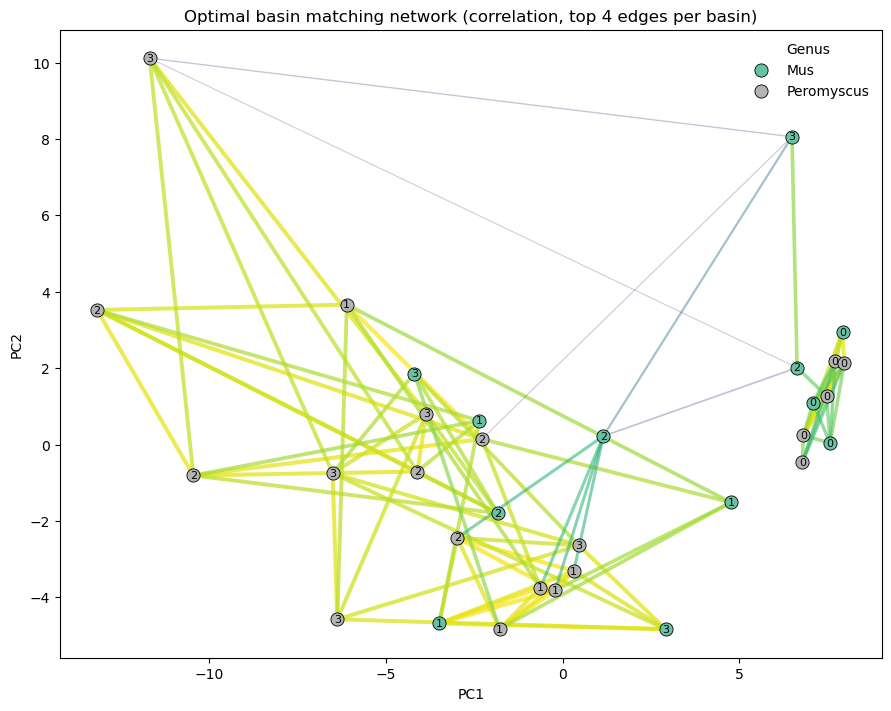

,metric,species_a,species_b,arm_a,arm_b,basin_distance,node_a,node_b,edge_key
0,correlation,Peromyscus_gossypinus,Peromyscus_leucopus,2,1,0.013486,Peromyscus_gossypinus|arm_2,Peromyscus_leucopus|arm_1,"(Peromyscus_gossypinus|arm_2, Peromyscus_leuco..."
1,correlation,Peromyscus_gossypinus,Peromyscus_maniculatus,1,1,0.013486,Peromyscus_gossypinus|arm_1,Peromyscus_maniculatus|arm_1,"(Peromyscus_gossypinus|arm_1, Peromyscus_manic..."
2,correlation,Peromyscus_gossypinus,Peromyscus_maniculatus,0,0,0.015631,Peromyscus_gossypinus|arm_0,Peromyscus_maniculatus|arm_0,"(Peromyscus_gossypinus|arm_0, Peromyscus_manic..."
3,correlation,Peromyscus_maniculatus,Peromyscus_polionotus,1,1,0.016280,Peromyscus_maniculatus|arm_1,Peromyscus_polionotus|arm_1,"(Peromyscus_maniculatus|arm_1, Peromyscus_poli..."
4,correlation,Peromyscus_gossypinus,Peromyscus_leucopus,1,2,0.020710,Peromyscus_gossypinus|arm_1,Peromyscus_leucopus|arm_2,"(Peromyscus_gossypinus|arm_1, Peromyscus_leuco..."
5,correlation,Mus_musculus,Peromyscus_polionotus,1,1,0.026910,Mus_musculus|arm_1,Peromyscus_polionotus|arm_1,"(Mus_musculus|arm_1, Peromyscus_polionotus|arm_1)"
6,correlation,Peromyscus_maniculatus,Peromyscus_polionotus,0,0,0.028244,Peromyscus_maniculatus|arm_0,Peromyscus_polionotus|arm_0,"(Peromyscus_maniculatus|arm_0, Peromyscus_poli..."
7,correlation,Mus_caroli,Mus_musculus,3,1,0.028730,Mus_caroli|arm_3,Mus_musculus|arm_1,"(Mus_caroli|arm_3, Mus_musculus|arm_1)"
8,correlation,Peromyscus_leucopus,Peromyscus_maniculatus,2,1,0.030257,Peromyscus_leucopus|arm_2,Peromyscus_maniculatus|arm_1,"(Peromyscus_leucopus|arm_2, Peromyscus_manicul..."
9,correlation,Peromyscus_californicus,Peromyscus_maniculatus,1,1,0.035845,Peromyscus_californicus|arm_1,Peromyscus_maniculatus|arm_1,"(Peromyscus_californicus|arm_1, Peromyscus_man..."


In [14]:
network_candidates = enrichment_matching_df.query('metric == @BASIN_VIS_METRIC').copy()
network_candidates['node_a'] = network_candidates.apply(lambda r: f"{r.species_a}|arm_{int(r.arm_a)}", axis=1)
network_candidates['node_b'] = network_candidates.apply(lambda r: f"{r.species_b}|arm_{int(r.arm_b)}", axis=1)
network_candidates['edge_key'] = network_candidates.apply(lambda r: tuple(sorted([r.node_a, r.node_b])), axis=1)

edge_rows = []
for node_id in basin_profile_meta['node_id']:
    incident = network_candidates[(network_candidates['node_a'] == node_id) | (network_candidates['node_b'] == node_id)]
    edge_rows.append(incident.nsmallest(BASIN_NETWORK_K_NEIGHBORS, 'basin_distance'))
network_edges = pd.concat(edge_rows, ignore_index=True).drop_duplicates('edge_key')
network_edges = network_edges.sort_values('basin_distance').reset_index(drop=True)
network_edges.to_csv(OUT_DIR / f'setM_basin_matching_network_edges_{BASIN_VIS_METRIC}.csv', index=False)

position = basin_embedding_df.set_index('node_id')[['PC1', 'PC2']].to_dict('index')
edge_distances = network_edges['basin_distance'].to_numpy(dtype=float)
edge_min, edge_max = edge_distances.min(), edge_distances.max()

fig, ax = plt.subplots(figsize=(8.8, 7.0), constrained_layout=True)
for _, edge in network_edges.iterrows():
    p0 = position[edge.node_a]
    p1 = position[edge.node_b]
    norm_dist = (edge.basin_distance - edge_min) / max(edge_max - edge_min, EPS)
    ax.plot(
        [p0['PC1'], p1['PC1']],
        [p0['PC2'], p1['PC2']],
        color=plt.cm.viridis_r(norm_dist),
        alpha=0.22 + 0.55 * (1 - norm_dist),
        linewidth=0.8 + 2.2 * (1 - norm_dist),
        zorder=1,
    )
for genus, group in basin_embedding_df.groupby('genus'):
    ax.scatter(group['PC1'], group['PC2'], s=90, label=genus, color=colors[genus], edgecolor='black', linewidth=0.6, zorder=3)
for _, row in basin_embedding_df.iterrows():
    ax.annotate(str(int(row.arm)), (row.PC1, row.PC2), ha='center', va='center', fontsize=8, zorder=4)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Optimal basin matching network ({BASIN_VIS_METRIC}, top {BASIN_NETWORK_K_NEIGHBORS} edges per basin)')
ax.legend(frameon=False, title='Genus')
plt.show()

display(network_edges.head(20))

## Idea 7: within-species basin geometry
This ignores cross-species arm labels and asks whether each species has a similar internal four-basin shape. Each species is represented by the sorted six pairwise distances among its own basins.

,genus,sorted_pair_distance_1,sorted_pair_distance_2,sorted_pair_distance_3,sorted_pair_distance_4,sorted_pair_distance_5,sorted_pair_distance_6,mean_within_basin_distance,std_within_basin_distance
species,,,,,,,,,
Mus_caroli,Mus,0.362653,0.931102,1.151678,1.664071,1.730327,1.935618,1.295908,0.541348
Mus_musculus,Mus,0.168370,0.660070,1.502529,1.512149,1.588201,1.906048,1.222894,0.604263
Mus_spretus,Mus,0.080542,0.220687,0.309296,1.821944,1.833543,1.930107,1.032686,0.832554
Peromyscus_californicus,Peromyscus,0.028804,0.041670,0.049469,1.863050,1.920703,1.924229,0.971321,0.931571
Peromyscus_gossypinus,Peromyscus,0.016976,0.060543,0.083611,1.928701,1.934690,1.958011,0.997089,0.943623
Peromyscus_leucopus,Peromyscus,0.095646,0.121425,0.233602,1.622249,1.826435,1.951853,0.975202,0.831629
Peromyscus_maniculatus,Peromyscus,0.046032,0.099118,0.132965,1.889853,1.929882,1.963434,1.010214,0.918104
Peromyscus_polionotus,Peromyscus,0.083258,0.162455,0.178429,1.820224,1.897560,1.950044,1.015328,0.875255


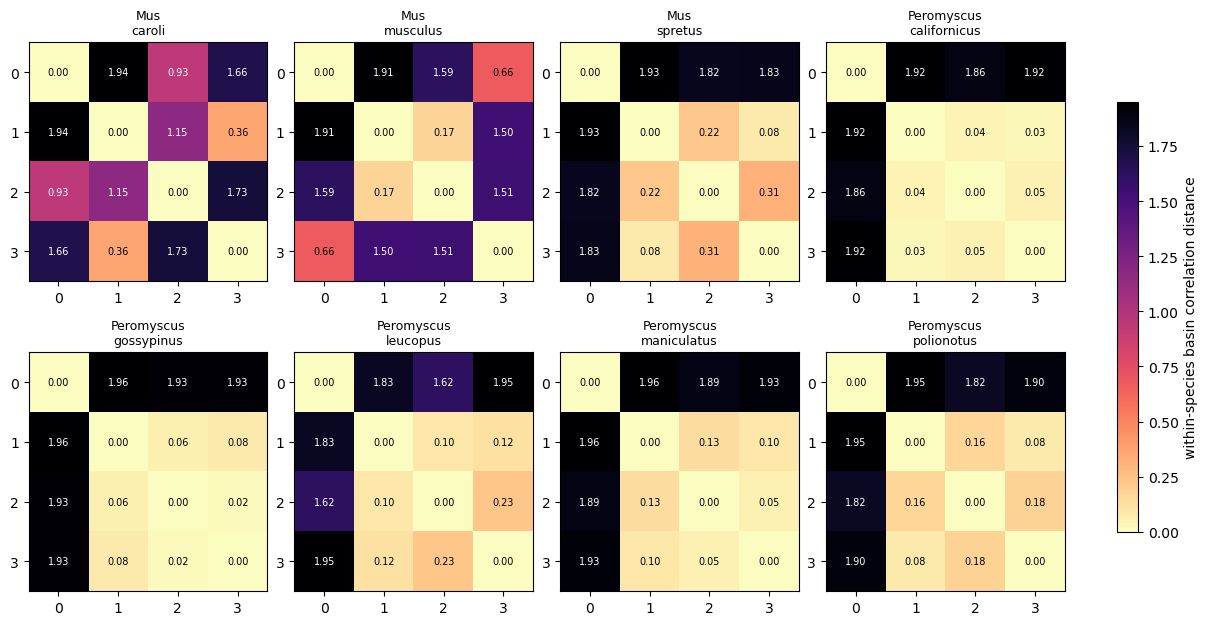

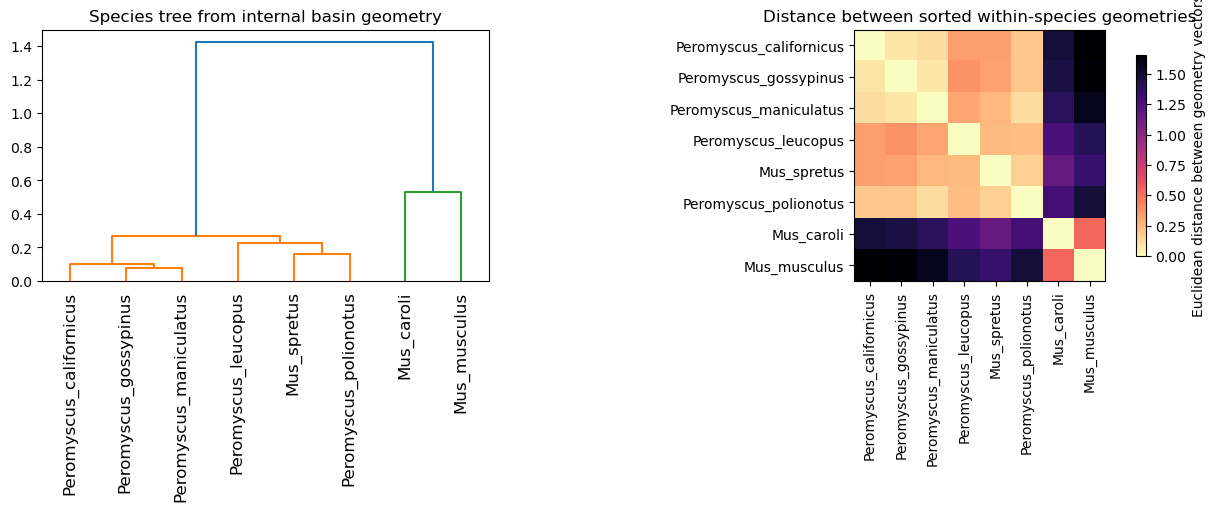

In [15]:
def within_basin_distance_matrix(enrichment_matrix, metric=BASIN_VIS_METRIC):
    arms = list(enrichment_matrix.index)
    out = np.zeros((len(arms), len(arms)), dtype=float)
    for i, arm_i in enumerate(arms):
        for j, arm_j in enumerate(arms):
            if j <= i:
                continue
            d = vector_distance(enrichment_matrix.loc[arm_i], enrichment_matrix.loc[arm_j], metric=metric)
            out[i, j] = out[j, i] = d
    return pd.DataFrame(out, index=arms, columns=arms)

geometry_rows = []
within_distance_matrices = {}
for species in enrichment_species_order:
    dist_df = within_basin_distance_matrix(setm_enrichment_matrices[species], metric=BASIN_VIS_METRIC)
    within_distance_matrices[species] = dist_df
    dist_df.to_csv(OUT_DIR / f'{species}_setM_within_basin_enrichment_{BASIN_VIS_METRIC}_distance.csv')
    upper = dist_df.to_numpy()[np.triu_indices(dist_df.shape[0], k=1)]
    sorted_upper = np.sort(upper)
    row = {'species': species, 'genus': species.split('_')[0]}
    row.update({f'sorted_pair_distance_{idx + 1}': float(value) for idx, value in enumerate(sorted_upper)})
    row['mean_within_basin_distance'] = float(np.mean(upper))
    row['std_within_basin_distance'] = float(np.std(upper))
    geometry_rows.append(row)

within_geometry_df = pd.DataFrame(geometry_rows).set_index('species')
within_geometry_df.to_csv(OUT_DIR / f'setM_within_species_basin_geometry_vectors_{BASIN_VIS_METRIC}.csv')
display(within_geometry_df)

geometry_features = within_geometry_df.filter(like='sorted_pair_distance_').to_numpy(dtype=float)
geometry_species_dist = np.zeros((len(enrichment_species_order), len(enrichment_species_order)), dtype=float)
for i in range(len(enrichment_species_order)):
    for j in range(i + 1, len(enrichment_species_order)):
        geometry_species_dist[i, j] = geometry_species_dist[j, i] = np.linalg.norm(geometry_features[i] - geometry_features[j])
geometry_species_dist_df = pd.DataFrame(geometry_species_dist, index=enrichment_species_order, columns=enrichment_species_order)
geometry_species_dist_df.to_csv(OUT_DIR / f'setM_within_basin_geometry_species_distance_{BASIN_VIS_METRIC}.csv')

fig, axes = plt.subplots(2, 4, figsize=(12, 6.2), constrained_layout=True)
for ax, species in zip(axes.ravel(), enrichment_species_order):
    dist_df = within_distance_matrices[species]
    im = ax.imshow(dist_df, cmap='magma_r')
    ax.set_title(species.replace('_', '\n'), fontsize=9)
    ax.set_xticks(range(dist_df.shape[0]), dist_df.columns)
    ax.set_yticks(range(dist_df.shape[0]), dist_df.index)
    for i in range(dist_df.shape[0]):
        for j in range(dist_df.shape[1]):
            ax.text(j, i, f'{dist_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7, color='white' if dist_df.iloc[i, j] > dist_df.to_numpy().max() * 0.45 else 'black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.72, label=f'within-species basin {BASIN_VIS_METRIC} distance')
plt.show()

condensed = squareform(geometry_species_dist_df.to_numpy(), checks=False)
link = linkage(condensed, method='average') if np.any(condensed > 0) else None
order = leaves_list(link) if link is not None else np.arange(len(enrichment_species_order))
ordered_species = [enrichment_species_order[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), gridspec_kw={'width_ratios': [1, 1.35]}, constrained_layout=True)
if link is not None:
    dendrogram(link, labels=enrichment_species_order, ax=axes[0], leaf_rotation=90)
else:
    axes[0].text(0.5, 0.5, 'all geometry distances are zero', ha='center', va='center')
axes[0].set_title('Species tree from internal basin geometry')
ordered_geometry = geometry_species_dist_df.loc[ordered_species, ordered_species]
im = axes[1].imshow(ordered_geometry, cmap='magma_r')
axes[1].set_xticks(range(len(ordered_species)), ordered_species, rotation=90)
axes[1].set_yticks(range(len(ordered_species)), ordered_species)
axes[1].set_title('Distance between sorted within-species geometries')
fig.colorbar(im, ax=axes[1], shrink=0.8, label='Euclidean distance between geometry vectors')
plt.show()

## Idea 8: basin selectivity and entropy profiles
For each species-specific basin, this asks how concentrated the MoSeq syllable distribution is. Low entropy means a basin is behaviorally selective; high enrichment norm means the basin strongly deviates from that species' overall syllable baseline.

,species,genus,arm,entropy_normalized,selectivity_1_minus_entropy,enrichment_l2_norm,mean_abs_enrichment,max_positive_enrichment,max_abs_enrichment,top_syllable,top_syllable_probability
0,Mus_caroli,Mus,0,0.803486,0.196514,2.656612,0.303955,0.481773,0.868366,11,0.237215
1,Mus_caroli,Mus,1,0.804547,0.195453,2.335182,0.285034,0.625181,0.625181,11,0.242040
2,Mus_caroli,Mus,2,0.771299,0.228701,3.003644,0.323134,0.797045,1.272619,11,0.283241
3,Mus_caroli,Mus,3,0.836025,0.163975,5.666189,0.577361,2.249777,2.249777,11,0.189385
4,Mus_musculus,Mus,0,0.888556,0.111444,4.280931,0.375881,0.204221,1.796750,14,0.079885
5,Mus_musculus,Mus,1,0.858794,0.141206,10.854273,1.390957,2.406842,2.546431,14,0.114022
6,Mus_musculus,Mus,2,0.831044,0.168956,8.855776,1.088304,2.417420,2.535246,23,0.149848
7,Mus_musculus,Mus,3,0.672404,0.327596,11.116209,1.279685,6.179029,6.179029,27,0.417592
8,Mus_spretus,Mus,0,0.848256,0.151744,2.290134,0.287242,0.421032,0.609411,14,0.138980
9,Mus_spretus,Mus,1,0.736708,0.263292,9.345559,1.120923,1.297173,2.795684,23,0.165477


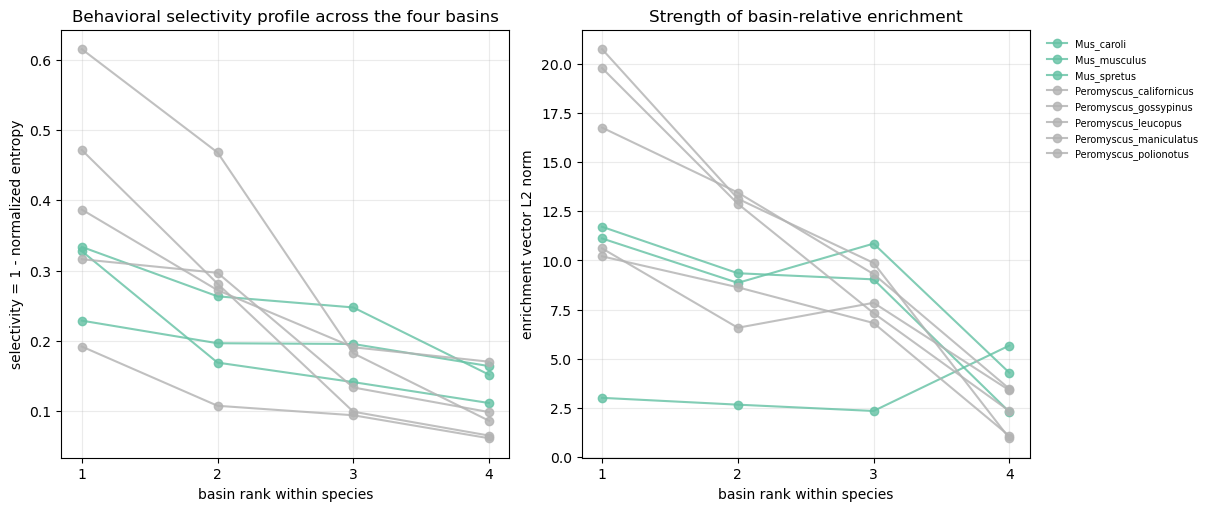

,mean_selectivity,max_selectivity,mean_enrichment_l2,max_enrichment_l2
species,,,,
Mus_caroli,0.196161,0.228701,3.415407,5.666189
Mus_musculus,0.187300,0.327596,8.776797,11.116209
Mus_spretus,0.249029,0.333618,8.095126,11.710851
Peromyscus_californicus,0.254969,0.386761,10.744462,16.759375
Peromyscus_gossypinus,0.211230,0.316083,6.678743,10.206559
Peromyscus_leucopus,0.337855,0.615045,11.176951,20.752608
Peromyscus_maniculatus,0.229259,0.471573,10.579857,19.788479
Peromyscus_polionotus,0.113675,0.191860,7.102835,10.610537


In [16]:
selectivity_rows = []
for species in enrichment_species_order:
    counts = setm_count_matrices[species].astype(float)
    probabilities = counts.div(np.maximum(counts.sum(axis=1), EPS), axis=0)
    enrichment = setm_enrichment_matrices[species]
    for arm in counts.index:
        p = probabilities.loc[arm].to_numpy(dtype=float)
        p = p / max(p.sum(), EPS)
        entropy = float(-np.sum(np.where(p > 0, p * np.log(p + EPS), 0.0)) / np.log(len(p)))
        enrich_vec = enrichment.loc[arm].to_numpy(dtype=float)
        selectivity_rows.append({
            'species': species,
            'genus': species.split('_')[0],
            'arm': int(arm),
            'entropy_normalized': entropy,
            'selectivity_1_minus_entropy': 1.0 - entropy,
            'enrichment_l2_norm': float(np.linalg.norm(enrich_vec)),
            'mean_abs_enrichment': float(np.mean(np.abs(enrich_vec))),
            'max_positive_enrichment': float(np.max(enrich_vec)),
            'max_abs_enrichment': float(np.max(np.abs(enrich_vec))),
            'top_syllable': int(probabilities.loc[arm].idxmax()),
            'top_syllable_probability': float(probabilities.loc[arm].max()),
        })

basin_selectivity_df = pd.DataFrame(selectivity_rows)
basin_selectivity_df.to_csv(OUT_DIR / 'setM_basin_selectivity_entropy_profiles.csv', index=False)
display(basin_selectivity_df.sort_values(['species', 'arm']).head(20))

ranked_rows = []
for species, group in basin_selectivity_df.groupby('species'):
    ranked = group.sort_values('selectivity_1_minus_entropy', ascending=False).reset_index(drop=True)
    for rank, (_, row) in enumerate(ranked.iterrows(), start=1):
        ranked_rows.append({
            'species': species,
            'genus': row['genus'],
            'rank_by_selectivity': rank,
            'arm': int(row['arm']),
            'selectivity_1_minus_entropy': row['selectivity_1_minus_entropy'],
            'enrichment_l2_norm': row['enrichment_l2_norm'],
            'mean_abs_enrichment': row['mean_abs_enrichment'],
        })
ranked_selectivity_df = pd.DataFrame(ranked_rows)
ranked_selectivity_df.to_csv(OUT_DIR / 'setM_basin_selectivity_ranked_by_species.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), constrained_layout=True)
for species, group in ranked_selectivity_df.groupby('species'):
    genus = group['genus'].iloc[0]
    axes[0].plot(group['rank_by_selectivity'], group['selectivity_1_minus_entropy'], marker='o', color=colors[genus], alpha=0.82, label=species)
    axes[1].plot(group['rank_by_selectivity'], group['enrichment_l2_norm'], marker='o', color=colors[genus], alpha=0.82, label=species)
axes[0].set_xlabel('basin rank within species')
axes[0].set_ylabel('selectivity = 1 - normalized entropy')
axes[0].set_title('Behavioral selectivity profile across the four basins')
axes[1].set_xlabel('basin rank within species')
axes[1].set_ylabel('enrichment vector L2 norm')
axes[1].set_title('Strength of basin-relative enrichment')
for ax in axes:
    ax.set_xticks([1, 2, 3, 4])
    ax.grid(alpha=0.25)
axes[1].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

summary = basin_selectivity_df.groupby('species').agg(
    mean_selectivity=('selectivity_1_minus_entropy', 'mean'),
    max_selectivity=('selectivity_1_minus_entropy', 'max'),
    mean_enrichment_l2=('enrichment_l2_norm', 'mean'),
    max_enrichment_l2=('enrichment_l2_norm', 'max'),
).sort_index()
summary.to_csv(OUT_DIR / 'setM_basin_selectivity_species_summary.csv')
display(summary)

## Behavior enrichment visualizations across species

These panels use the setM basin-relative syllable enrichment vectors after aligning each species' arms to the reference species by optimal enrichment matching. They show which MoSeq syllables drive cross-species differences within matched slow-mode basins.

In [17]:
BEHAVIOR_VIS_DIR = OUT_DIR / 'behavior_enrichment_visualizations'
BEHAVIOR_VIS_DIR.mkdir(parents=True, exist_ok=True)
BEHAVIOR_VIS_METRIC = 'correlation'
TOP_SYLLABLES_PER_ARM = 18
DOTPLOT_TOP_SYLLABLES = 18


def matched_arm_map_to_reference(species, metric=BEHAVIOR_VIS_METRIC):
    if species == REFERENCE_SPECIES:
        return {int(arm): int(arm) for arm in setm_enrichment_matrices[species].index}
    result = matched_enrichment_species_distance(
        setm_enrichment_matrices[REFERENCE_SPECIES],
        setm_enrichment_matrices[species],
        metric=metric,
    )
    ref_arms = list(setm_enrichment_matrices[REFERENCE_SPECIES].index)
    species_arms = list(setm_enrichment_matrices[species].index)
    return {
        int(ref_arms[row]): int(species_arms[col])
        for row, col in zip(result['rows'], result['cols'])
    }


def arm_syllable_probability_matrix(counts):
    counts = counts.astype(float)
    return counts.div(counts.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)


def syllable_label(syllable):
    return syllable_label_map.get(int(syllable), str(int(syllable)))


aligned_rows = []
for species in enrichment_species_order:
    mapping = matched_arm_map_to_reference(species)
    enrichment = setm_enrichment_matrices[species]
    probabilities = arm_syllable_probability_matrix(setm_count_matrices[species])
    genus = species.split('_')[0]
    for reference_arm, species_arm in sorted(mapping.items()):
        for syllable in enrichment.columns:
            syllable_int = int(syllable)
            aligned_rows.append({
                'species': species,
                'genus': genus,
                'reference_species': REFERENCE_SPECIES,
                'reference_arm': int(reference_arm),
                'matched_species_arm': int(species_arm),
                'syllable': syllable_int,
                'syllable_label': syllable_label(syllable_int),
                'moseq_syllable_name': syllable_name_map.get(syllable_int),
                'moseq_category': syllable_category_map.get(syllable_int),
                'log2_enrichment': float(enrichment.loc[species_arm, syllable]),
                'arm_syllable_probability': float(probabilities.loc[species_arm, syllable]),
            })

aligned_enrichment_long = pd.DataFrame(aligned_rows)
aligned_enrichment_path = BEHAVIOR_VIS_DIR / f'setM_reference_aligned_syllable_enrichment_to_{REFERENCE_SPECIES}.csv'
aligned_enrichment_long.to_csv(aligned_enrichment_path, index=False)
display(aligned_enrichment_long.head())
print('wrote', aligned_enrichment_path)

,species,genus,reference_species,reference_arm,matched_species_arm,syllable,syllable_label,moseq_syllable_name,moseq_category,log2_enrichment,arm_syllable_probability
0,Mus_caroli,Mus,Peromyscus_polionotus,0,0,0,0: head_low,None,None,-0.299940,0.018344
1,Mus_caroli,Mus,Peromyscus_polionotus,0,0,1,1: head_down,None,None,-0.053669,0.059751
2,Mus_caroli,Mus,Peromyscus_polionotus,0,0,2,2: sniff_floor,None,None,-0.194103,0.008524
3,Mus_caroli,Mus,Peromyscus_polionotus,0,0,3,3: step_to_stop,None,None,-0.269616,0.009616
4,Mus_caroli,Mus,Peromyscus_polionotus,0,0,4,4: turn_left,None,None,-0.274639,0.021942


wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_reference_aligned_syllable_enrichment_to_Peromyscus_polionotus.csv


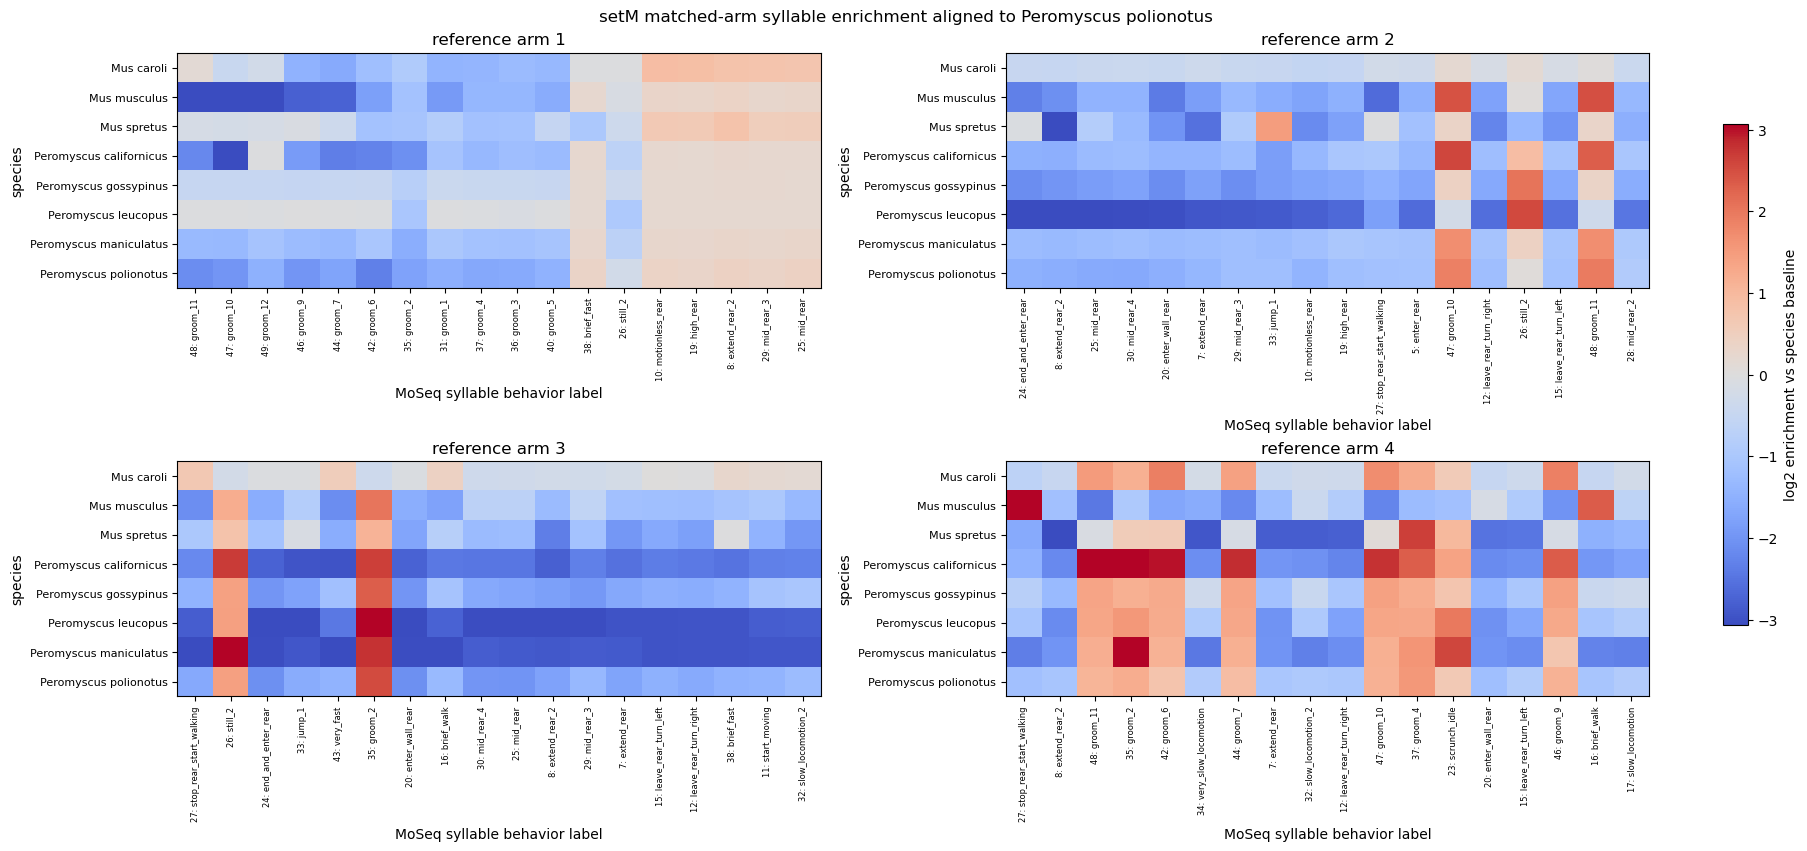

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_species_by_syllable_enrichment_heatmaps.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_heatmap_values.csv


In [18]:
# Matched-arm heatmaps: rows are species, columns are the most variable syllables for that reference arm.
species_order_for_plots = enrichment_species_order
reference_arm_order = sorted(aligned_enrichment_long['reference_arm'].unique())
heatmap_rows = []

fig, axes = plt.subplots(
    2,
    int(np.ceil(len(reference_arm_order) / 2)),
    figsize=(18, 8.4),
    constrained_layout=True,
    squeeze=False,
)

for ax, reference_arm in zip(axes.flat, reference_arm_order):
    arm_df = aligned_enrichment_long.query('reference_arm == @reference_arm')
    syllable_scores = (
        arm_df.groupby('syllable')['log2_enrichment']
        .agg(lambda values: float(np.nanmax(np.abs(values))))
        .sort_values(ascending=False)
    )
    top_syllables = list(syllable_scores.head(TOP_SYLLABLES_PER_ARM).index)
    top_labels = [syllable_label(s) for s in top_syllables]
    matrix = (
        arm_df[arm_df['syllable'].isin(top_syllables)]
        .pivot_table(index='species', columns='syllable', values='log2_enrichment', aggfunc='mean')
        .reindex(index=species_order_for_plots, columns=top_syllables)
    )
    vmax = np.nanpercentile(np.abs(matrix.to_numpy(dtype=float)), 98)
    vmax = max(vmax, 1e-6)
    im = ax.imshow(matrix.to_numpy(dtype=float), aspect='auto', cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(f'reference arm {reference_arm + 1}')
    ax.set_xticks(np.arange(len(top_syllables)))
    ax.set_xticklabels(top_labels, rotation=90, fontsize=6)
    ax.set_yticks(np.arange(len(species_order_for_plots)))
    ax.set_yticklabels([s.replace('_', ' ') for s in species_order_for_plots], fontsize=8)
    ax.set_xlabel('MoSeq syllable behavior label')
    ax.set_ylabel('species')
    for species in species_order_for_plots:
        for syllable in top_syllables:
            value = matrix.loc[species, syllable]
            heatmap_rows.append({
                'reference_arm': int(reference_arm),
                'species': species,
                'syllable': int(syllable),
                'syllable_label': syllable_label(syllable),
                'moseq_syllable_name': syllable_name_map.get(int(syllable)),
                'moseq_category': syllable_category_map.get(int(syllable)),
                'log2_enrichment': float(value),
            })

for ax in axes.flat[len(reference_arm_order):]:
    ax.set_visible(False)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.78, label='log2 enrichment vs species baseline')
fig.suptitle(f'setM matched-arm syllable enrichment aligned to {REFERENCE_SPECIES.replace("_", " ")}')
heatmap_png = BEHAVIOR_VIS_DIR / 'setM_matched_arm_species_by_syllable_enrichment_heatmaps.png'
heatmap_pdf = BEHAVIOR_VIS_DIR / 'setM_matched_arm_species_by_syllable_enrichment_heatmaps.pdf'
fig.savefig(heatmap_png, dpi=220)
fig.savefig(heatmap_pdf)
plt.show()

heatmap_export = pd.DataFrame(heatmap_rows)
heatmap_export_path = BEHAVIOR_VIS_DIR / 'setM_matched_arm_heatmap_values.csv'
heatmap_export.to_csv(heatmap_export_path, index=False)
print('wrote', heatmap_png)
print('wrote', heatmap_export_path)

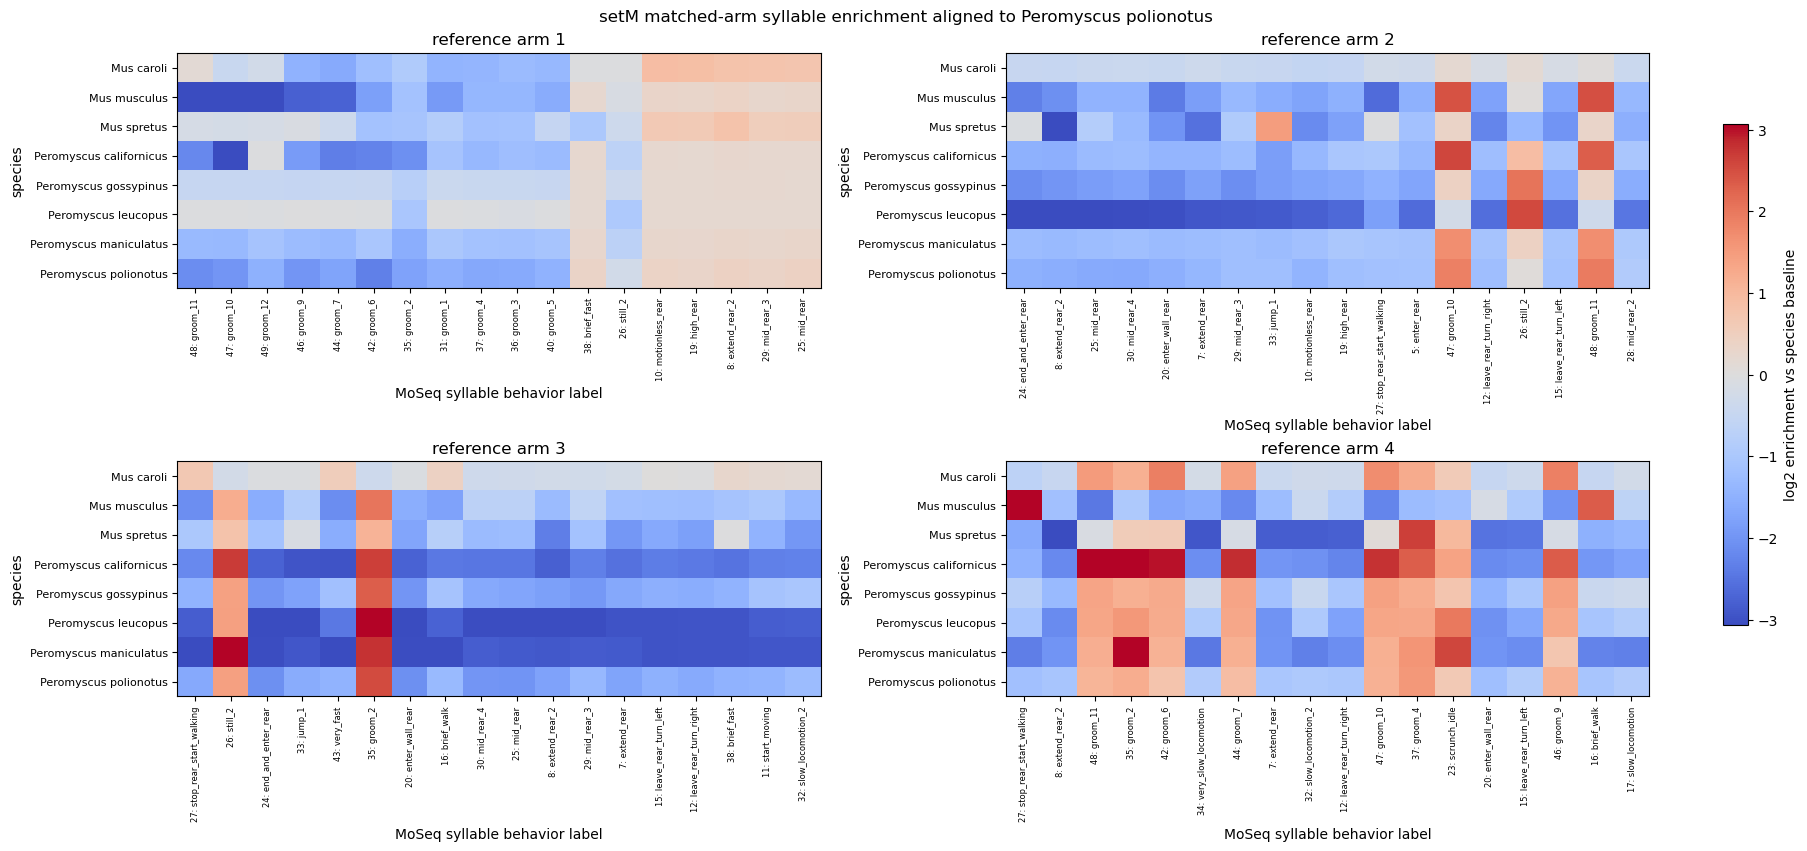

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_species_by_syllable_enrichment_heatmaps.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_heatmap_values.csv


In [34]:
# Matched-arm heatmaps: rows are species, columns are the most variable syllables for that reference arm.
species_order_for_plots = enrichment_species_order
reference_arm_order = sorted(aligned_enrichment_long['reference_arm'].unique())
heatmap_rows = []

fig, axes = plt.subplots(
    2,
    int(np.ceil(len(reference_arm_order) / 2)),
    figsize=(18, 8.4),
    constrained_layout=True,
    squeeze=False,
)

for ax, reference_arm in zip(axes.flat, reference_arm_order):
    arm_df = aligned_enrichment_long.query('reference_arm == @reference_arm')
    syllable_scores = (
        arm_df.groupby('syllable')['log2_enrichment']
        .agg(lambda values: float(np.nanmax(np.abs(values))))
        .sort_values(ascending=False)
    )
    top_syllables = list(syllable_scores.head(TOP_SYLLABLES_PER_ARM).index)
    top_labels = [syllable_label(s) for s in top_syllables]
    matrix = (
        arm_df[arm_df['syllable'].isin(top_syllables)]
        .pivot_table(index='species', columns='syllable', values='log2_enrichment', aggfunc='mean')
        .reindex(index=species_order_for_plots, columns=top_syllables)
    )
    vmax = np.nanpercentile(np.abs(matrix.to_numpy(dtype=float)), 98)
    vmax = max(vmax, 1e-6)
    im = ax.imshow(matrix.to_numpy(dtype=float), aspect='auto', cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax.set_title(f'reference arm {reference_arm + 1}')
    ax.set_xticks(np.arange(len(top_syllables)))
    ax.set_xticklabels(top_labels, rotation=90, fontsize=6)
    ax.set_yticks(np.arange(len(species_order_for_plots)))
    ax.set_yticklabels([s.replace('_', ' ') for s in species_order_for_plots], fontsize=8)
    ax.set_xlabel('MoSeq syllable behavior label')
    ax.set_ylabel('species')
    for species in species_order_for_plots:
        for syllable in top_syllables:
            value = matrix.loc[species, syllable]
            heatmap_rows.append({
                'reference_arm': int(reference_arm),
                'species': species,
                'syllable': int(syllable),
                'syllable_label': syllable_label(syllable),
                'moseq_syllable_name': syllable_name_map.get(int(syllable)),
                'moseq_category': syllable_category_map.get(int(syllable)),
                'log2_enrichment': float(value),
            })

for ax in axes.flat[len(reference_arm_order):]:
    ax.set_visible(False)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.78, label='log2 enrichment vs species baseline')
fig.suptitle(f'setM matched-arm syllable enrichment aligned to {REFERENCE_SPECIES.replace("_", " ")}')
heatmap_png = BEHAVIOR_VIS_DIR / 'setM_matched_arm_species_by_syllable_enrichment_heatmaps.png'
heatmap_pdf = BEHAVIOR_VIS_DIR / 'setM_matched_arm_species_by_syllable_enrichment_heatmaps.pdf'
fig.savefig(heatmap_png, dpi=220)
fig.savefig(heatmap_pdf)
plt.show()

heatmap_export = pd.DataFrame(heatmap_rows)
heatmap_export_path = BEHAVIOR_VIS_DIR / 'setM_matched_arm_heatmap_values.csv'
heatmap_export.to_csv(heatmap_export_path, index=False)
print('wrote', heatmap_png)
print('wrote', heatmap_export_path)

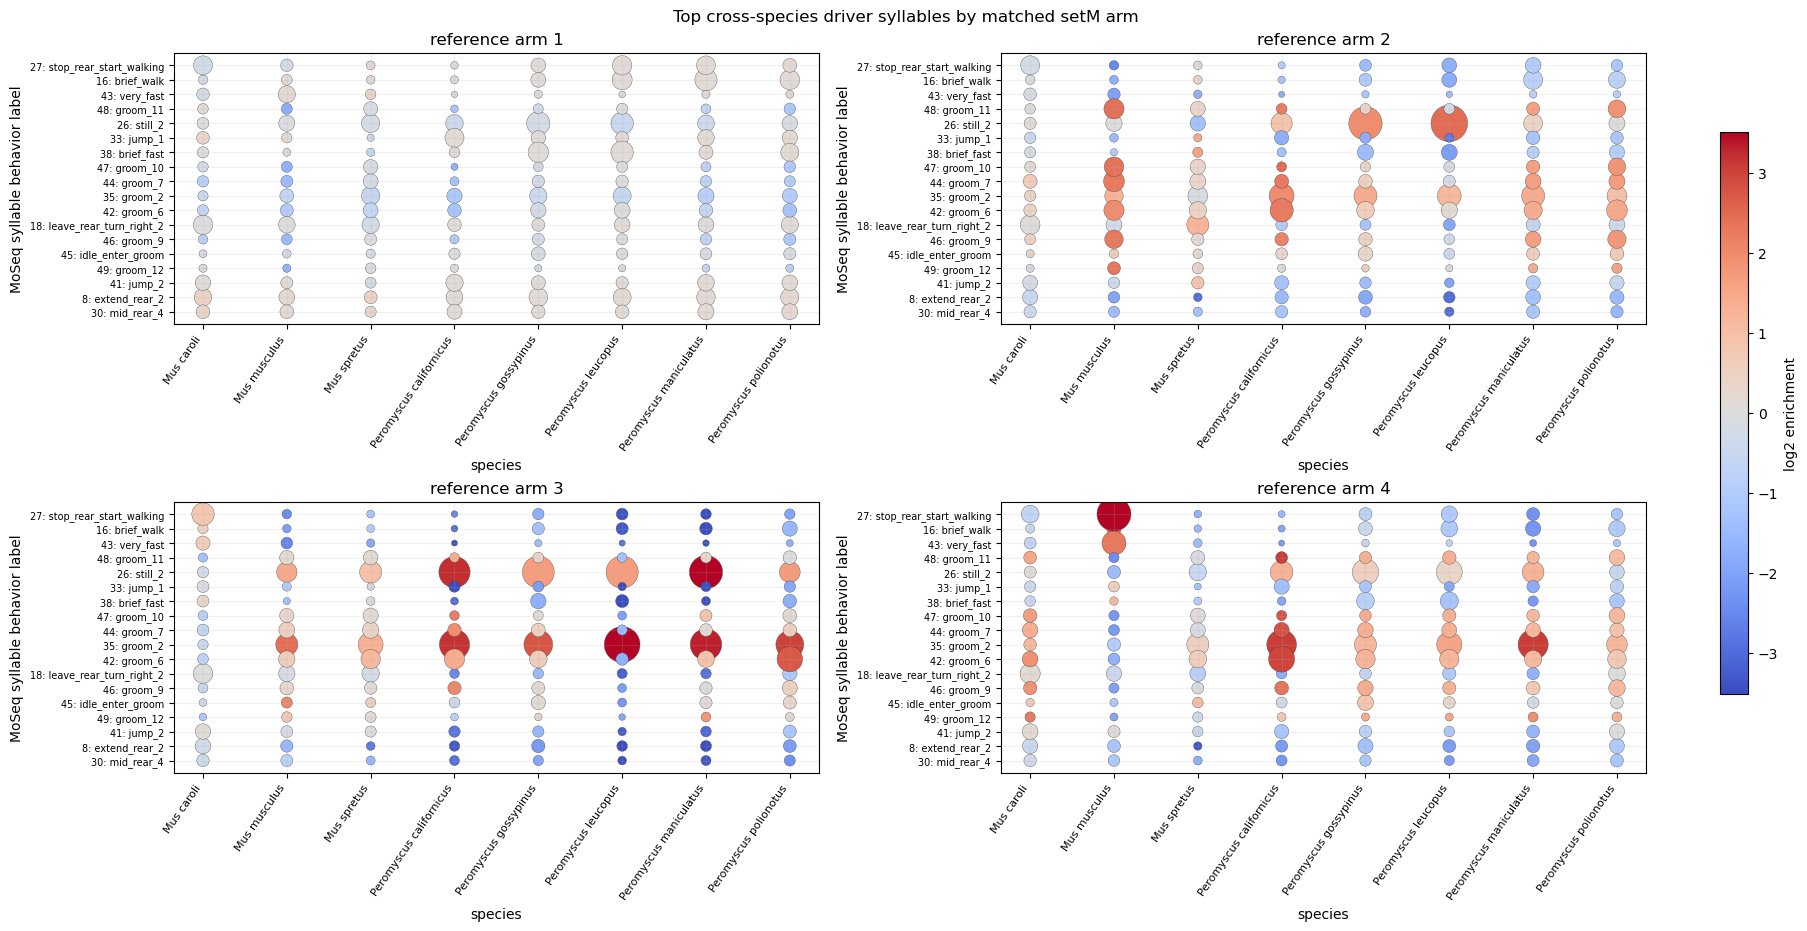

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_top_driver_syllable_dotplot.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_top_driver_syllable_dotplot_values.csv


In [19]:
# Dot plot: color is enrichment; size is p(syllable | matched arm, species).
driver_syllables = (
    aligned_enrichment_long.groupby('syllable')['log2_enrichment']
    .agg(lambda values: float(np.nanmax(values) - np.nanmin(values)))
    .sort_values(ascending=False)
    .head(DOTPLOT_TOP_SYLLABLES)
    .index
    .tolist()
)
driver_syllable_labels = [syllable_label(s) for s in driver_syllables]
dot_df = aligned_enrichment_long[aligned_enrichment_long['syllable'].isin(driver_syllables)].copy()
dot_df['species_plot'] = pd.Categorical(dot_df['species'], categories=species_order_for_plots, ordered=True)
dot_df['syllable_plot'] = pd.Categorical(dot_df['syllable'], categories=driver_syllables[::-1], ordered=True)
dot_vmax = np.nanpercentile(np.abs(dot_df['log2_enrichment']), 98)
dot_vmax = max(dot_vmax, 1e-6)

fig, axes = plt.subplots(
    2,
    int(np.ceil(len(reference_arm_order) / 2)),
    figsize=(18, 9.2),
    constrained_layout=True,
    squeeze=False,
)
for ax, reference_arm in zip(axes.flat, reference_arm_order):
    arm_df = dot_df.query('reference_arm == @reference_arm')
    x = arm_df['species_plot'].cat.codes.to_numpy()
    y = arm_df['syllable_plot'].cat.codes.to_numpy()
    sizes = 18 + 900 * np.sqrt(arm_df['arm_syllable_probability'].to_numpy(dtype=float))
    sc = ax.scatter(
        x,
        y,
        s=sizes,
        c=arm_df['log2_enrichment'],
        cmap='coolwarm',
        vmin=-dot_vmax,
        vmax=dot_vmax,
        edgecolors='0.25',
        linewidths=0.25,
    )
    ax.set_title(f'reference arm {reference_arm + 1}')
    ax.set_xticks(np.arange(len(species_order_for_plots)))
    ax.set_xticklabels([s.replace('_', ' ') for s in species_order_for_plots], rotation=55, ha='right', fontsize=8)
    ax.set_yticks(np.arange(len(driver_syllables)))
    ax.set_yticklabels(driver_syllable_labels[::-1], fontsize=7)
    ax.set_xlabel('species')
    ax.set_ylabel('MoSeq syllable behavior label')
    ax.grid(alpha=0.18)

for ax in axes.flat[len(reference_arm_order):]:
    ax.set_visible(False)

fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.78, label='log2 enrichment')
fig.suptitle('Top cross-species driver syllables by matched setM arm')
dotplot_png = BEHAVIOR_VIS_DIR / 'setM_matched_arm_top_driver_syllable_dotplot.png'
dotplot_pdf = BEHAVIOR_VIS_DIR / 'setM_matched_arm_top_driver_syllable_dotplot.pdf'
fig.savefig(dotplot_png, dpi=220)
fig.savefig(dotplot_pdf)
plt.show()

dotplot_values_path = BEHAVIOR_VIS_DIR / 'setM_matched_arm_top_driver_syllable_dotplot_values.csv'
dot_df.to_csv(dotplot_values_path, index=False)
print('wrote', dotplot_png)
print('wrote', dotplot_values_path)

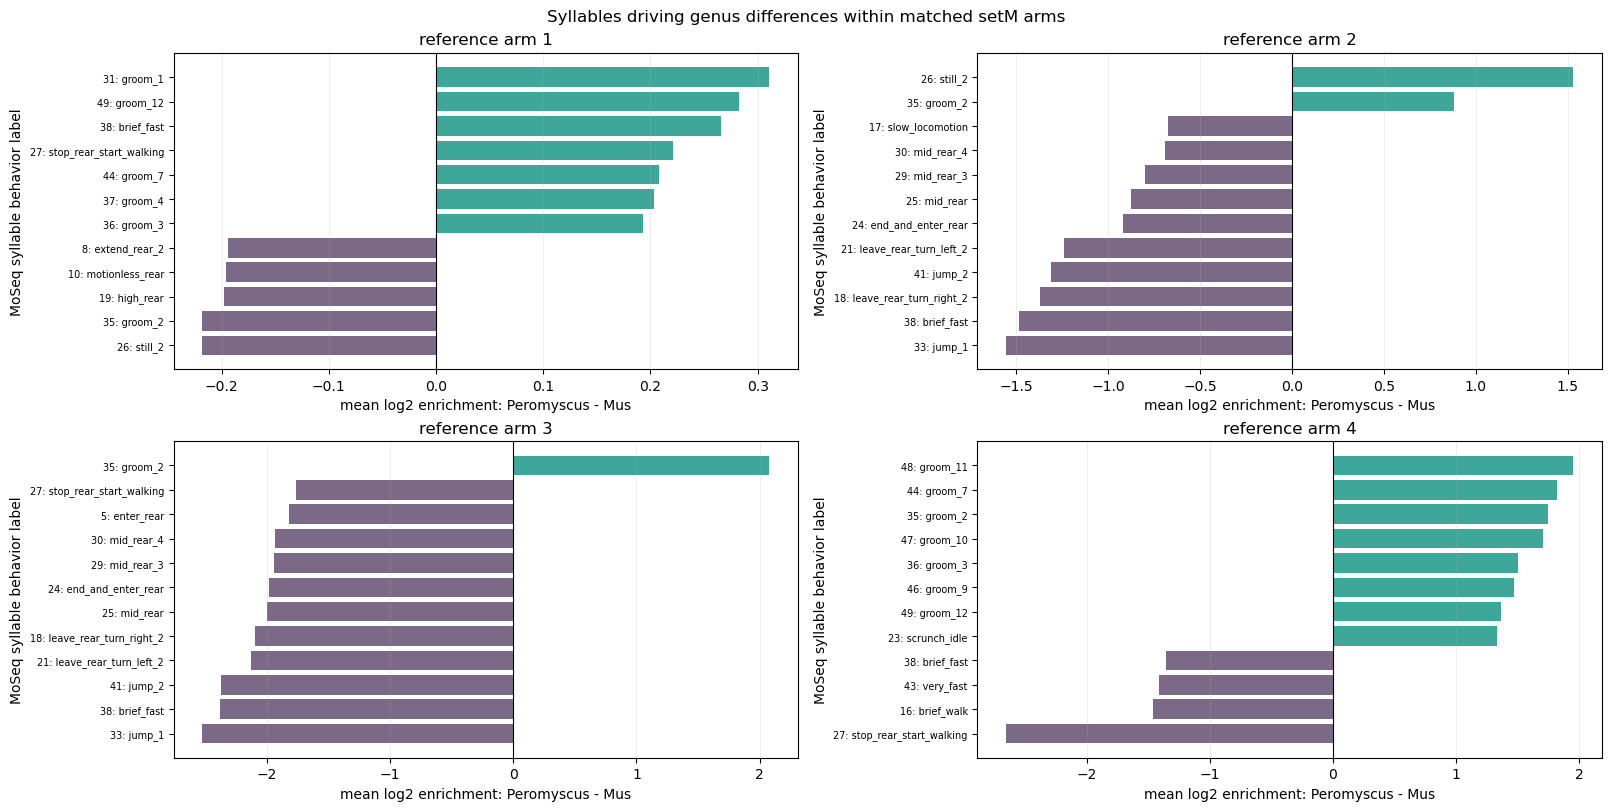

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_genus_enrichment_contrast.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/behavior_enrichment_visualizations/setM_matched_arm_genus_contrast_top_syllables.png


In [20]:
# Genus contrast drivers: mean Peromyscus enrichment minus mean Mus enrichment for each matched arm/syllable.
genus_means = (
    aligned_enrichment_long
    .groupby(['reference_arm', 'syllable', 'genus'])['log2_enrichment']
    .mean()
    .unstack('genus')
)
if {'Mus', 'Peromyscus'} <= set(genus_means.columns):
    genus_contrast = genus_means.copy()
    genus_contrast['Peromyscus_minus_Mus'] = genus_contrast['Peromyscus'] - genus_contrast['Mus']
    genus_contrast = genus_contrast.reset_index()
    genus_contrast['syllable_label'] = genus_contrast['syllable'].map(lambda value: syllable_label(value))
    genus_contrast['moseq_syllable_name'] = genus_contrast['syllable'].map(lambda value: syllable_name_map.get(int(value)))
    genus_contrast['moseq_category'] = genus_contrast['syllable'].map(lambda value: syllable_category_map.get(int(value)))
    genus_contrast_path = BEHAVIOR_VIS_DIR / 'setM_matched_arm_genus_enrichment_contrast.csv'
    genus_contrast.to_csv(genus_contrast_path, index=False)

    fig, axes = plt.subplots(2, int(np.ceil(len(reference_arm_order) / 2)), figsize=(16, 8.0), constrained_layout=True, squeeze=False)
    for ax, reference_arm in zip(axes.flat, reference_arm_order):
        arm_contrast = genus_contrast.query('reference_arm == @reference_arm').copy()
        arm_contrast['abs_delta'] = arm_contrast['Peromyscus_minus_Mus'].abs()
        top = arm_contrast.sort_values('abs_delta', ascending=False).head(12).sort_values('Peromyscus_minus_Mus')
        colors_bar = np.where(top['Peromyscus_minus_Mus'] >= 0, '#2a9d8f', '#6d597a')
        ax.barh(top['syllable_label'], top['Peromyscus_minus_Mus'], color=colors_bar, alpha=0.9)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'reference arm {reference_arm + 1}')
        ax.set_xlabel('mean log2 enrichment: Peromyscus - Mus')
        ax.set_ylabel('MoSeq syllable behavior label')
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='x', alpha=0.22)

    for ax in axes.flat[len(reference_arm_order):]:
        ax.set_visible(False)

    fig.suptitle('Syllables driving genus differences within matched setM arms')
    contrast_png = BEHAVIOR_VIS_DIR / 'setM_matched_arm_genus_contrast_top_syllables.png'
    contrast_pdf = BEHAVIOR_VIS_DIR / 'setM_matched_arm_genus_contrast_top_syllables.pdf'
    fig.savefig(contrast_png, dpi=220)
    fig.savefig(contrast_pdf)
    plt.show()

    print('wrote', genus_contrast_path)
    print('wrote', contrast_png)
else:
    print('Skipping genus contrast: expected both Mus and Peromyscus genera.')

## Species classifier from chi trajectory windows

This mirrors the genus chi-window classifier, but predicts the individual species. To avoid using arbitrary native arm labels as a coordinate system, each species' setM `chi` columns are first aligned to `REFERENCE_SPECIES` using the enrichment-vector basin matching above. Features summarize short windows of `chi[states]`: arm occupancy, arm variability, hard-arm occupancy, soft velocity, hard switching, dwell durations, and transition structure.

In [21]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SPECIES_CLASSIFIER_DIR = OUT_DIR / 'species_chi_trajectory_classifier'
SPECIES_CLASSIFIER_DIR.mkdir(parents=True, exist_ok=True)

SPECIES_CLASSIFIER_FS = 120.0
SPECIES_CLASSIFIER_WINDOW_SECONDS = (5, 10, 20, 40, 60)
SPECIES_CLASSIFIER_STRIDE_FRACTION = 0.5
SPECIES_CLASSIFIER_MAX_WINDOWS_PER_RECORDING = 80
SPECIES_CLASSIFIER_MAX_WINDOWS_PER_SPECIES = 2500
SPECIES_CLASSIFIER_N_SPLITS = 10
SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS = 20
SPECIES_CLASSIFIER_SEED = 14


def setm_arm_path(species):
    species_dir = SETM_ROOT / species
    preferred = species_dir / f'{species}_arms_setM.npz'
    if preferred.exists():
        return preferred
    matches = sorted(species_dir.glob('*_arms_setM.npz'))
    if not matches:
        raise FileNotFoundError(f'No setM arm file found for {species} under {species_dir}')
    return matches[0]


def load_setm_chi(species):
    with np.load(setm_arm_path(species), allow_pickle=True) as result:
        chi = np.asarray(result['chi'], dtype=float)
    chi = np.clip(chi, 0.0, None)
    return chi / np.maximum(chi.sum(axis=1, keepdims=True), EPS)


def state_files_for_species(species):
    states_dir = SETM_ROOT / species / 'states'
    return sorted(states_dir.glob('*_states.npy')) if states_dir.exists() else []


def reference_aligned_chi(species):
    chi = load_setm_chi(species)
    mapping = matched_arm_map_to_reference(species, metric=BEHAVIOR_VIS_METRIC)
    reference_arms = sorted(mapping)
    aligned = np.zeros((chi.shape[0], len(reference_arms)), dtype=float)
    for col_idx, reference_arm in enumerate(reference_arms):
        species_arm = mapping[reference_arm]
        aligned[:, col_idx] = chi[:, species_arm]
    return aligned, reference_arms


def sample_window_starts(n_frames, window_frames, stride_frames, max_windows, rng):
    if n_frames < window_frames:
        return np.array([], dtype=int)
    starts = np.arange(0, n_frames - window_frames + 1, stride_frames, dtype=int)
    if starts.size > max_windows:
        starts = np.sort(rng.choice(starts, size=max_windows, replace=False))
    return starts


def run_lengths(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return np.array([], dtype=float)
    changes = np.flatnonzero(labels[1:] != labels[:-1]) + 1
    starts = np.r_[0, changes]
    stops = np.r_[changes, labels.size]
    return (stops - starts).astype(float)


def chi_window_features(window_chi):
    window_chi = np.asarray(window_chi, dtype=float)
    hard = np.argmax(window_chi, axis=1)
    n_arms = window_chi.shape[1]
    entropy = -(window_chi * np.log(np.maximum(window_chi, EPS))).sum(axis=1) / np.log(max(n_arms, 2))
    max_chi = window_chi.max(axis=1)
    arm_mass = window_chi.mean(axis=0)
    arm_std = window_chi.std(axis=0)
    hard_mass = np.bincount(hard, minlength=n_arms).astype(float)
    hard_mass = hard_mass / max(hard_mass.sum(), EPS)
    if window_chi.shape[0] > 1:
        soft_velocity_by_arm = np.abs(np.diff(window_chi, axis=0)).mean(axis=0)
        soft_step = np.abs(np.diff(window_chi, axis=0)).sum(axis=1)
        hard_switch = hard[1:] != hard[:-1]
        switch_rate = float(hard_switch.mean())
        transition = np.zeros((n_arms, n_arms), dtype=float)
        np.add.at(transition, (hard[:-1], hard[1:]), 1.0)
        transition = transition / max(transition.sum(), EPS)
    else:
        soft_velocity_by_arm = np.zeros(n_arms, dtype=float)
        soft_step = np.array([0.0])
        switch_rate = 0.0
        transition = np.zeros((n_arms, n_arms), dtype=float)
    dwell = run_lengths(hard)
    dwell = dwell if dwell.size else np.array([0.0])
    scalar = np.array([
        entropy.mean(), entropy.std(), max_chi.mean(), max_chi.std(),
        soft_step.mean(), soft_step.std(), switch_rate,
        dwell.mean(), np.median(dwell), dwell.max(),
    ], dtype=float)
    return np.concatenate([arm_mass, arm_std, hard_mass, soft_velocity_by_arm, transition.ravel(), scalar])


def build_species_window_table():
    rng = np.random.default_rng(SPECIES_CLASSIFIER_SEED)
    rows = []
    for species in enrichment_species_order:
        chi, reference_arms = reference_aligned_chi(species)
        for state_path in state_files_for_species(species):
            states = np.load(state_path, mmap_mode='r')
            states = np.asarray(states, dtype=int)
            valid = (states >= 0) & (states < chi.shape[0])
            valid_fraction = float(valid.mean()) if valid.size else 0.0
            states = states[valid]
            if states.size == 0:
                continue
            trajectory = chi[states]
            recording_id = f'{species}/{state_path.stem}'
            for window_seconds in SPECIES_CLASSIFIER_WINDOW_SECONDS:
                window_frames = max(2, int(round(window_seconds * SPECIES_CLASSIFIER_FS)))
                stride_frames = max(1, int(round(window_frames * SPECIES_CLASSIFIER_STRIDE_FRACTION)))
                starts = sample_window_starts(
                    len(states), window_frames, stride_frames,
                    SPECIES_CLASSIFIER_MAX_WINDOWS_PER_RECORDING, rng,
                )
                for start in starts:
                    stop = start + window_frames
                    rows.append({
                        'window_seconds': float(window_seconds),
                        'species': species,
                        'genus': species.split('_')[0],
                        'recording_id': recording_id,
                        'state_file': str(state_path),
                        'window_start': int(start),
                        'window_stop': int(stop),
                        'valid_state_fraction': valid_fraction,
                        'n_reference_arms': len(reference_arms),
                        'features': chi_window_features(trajectory[start:stop]),
                    })
    return pd.DataFrame(rows)


def balance_species_windows(window_df):
    balanced = []
    for (window_seconds, species), sub in window_df.groupby(['window_seconds', 'species'], sort=True):
        if len(sub) > SPECIES_CLASSIFIER_MAX_WINDOWS_PER_SPECIES:
            sub = sub.sample(n=SPECIES_CLASSIFIER_MAX_WINDOWS_PER_SPECIES, random_state=SPECIES_CLASSIFIER_SEED)
        balanced.append(sub)
    return pd.concat(balanced, ignore_index=True) if balanced else window_df


species_window_df = balance_species_windows(build_species_window_table())
if species_window_df.empty:
    raise RuntimeError('No setM chi trajectory windows could be built for species classification.')

species_window_summary = (
    species_window_df
    .groupby(['window_seconds', 'species'], sort=True)
    .agg(
        n_windows=('species', 'size'),
        n_recordings=('recording_id', 'nunique'),
        median_valid_state_fraction=('valid_state_fraction', 'median'),
    )
    .reset_index()
)
species_window_summary_path = SPECIES_CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_summary.csv'
species_window_summary.to_csv(species_window_summary_path, index=False)
display(species_window_summary)
print('wrote', species_window_summary_path)

,window_seconds,species,n_windows,n_recordings,median_valid_state_fraction
0,5.0,Mus_caroli,1200,15,1.0
1,5.0,Mus_musculus,2500,93,1.0
2,5.0,Mus_spretus,2500,39,1.0
3,5.0,Peromyscus_californicus,1840,23,1.0
4,5.0,Peromyscus_gossypinus,1600,20,1.0
5,5.0,Peromyscus_leucopus,1120,14,1.0
6,5.0,Peromyscus_maniculatus,2500,129,1.0
7,5.0,Peromyscus_polionotus,2500,44,1.0
8,10.0,Mus_caroli,1200,15,1.0
9,10.0,Mus_musculus,2500,93,1.0


wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_chi_trajectory_window_summary.csv


In [22]:
def species_recording_split(meta_df, split_idx):
    rng = np.random.default_rng(SPECIES_CLASSIFIER_SEED + 1009 * split_idx)
    train_groups = set()
    test_groups = set()
    for species, sub in meta_df[['species', 'recording_id']].drop_duplicates().groupby('species', sort=True):
        groups = rng.permutation(sub['recording_id'].to_numpy())
        if groups.size < 2:
            train_groups.update(groups)
            continue
        n_test = max(1, int(round(0.25 * groups.size)))
        test_groups.update(groups[:n_test])
        train_groups.update(groups[n_test:])
    return train_groups, test_groups


def species_feature_matrix(mode_window_df):
    return np.vstack(mode_window_df['features'].to_numpy())


species_classes = sorted(species_window_df['species'].unique())
species_accuracy_rows = []
target_predictions = []

for window_seconds, sub in species_window_df.groupby('window_seconds', sort=True):
    sub = sub.reset_index(drop=True)
    X = species_feature_matrix(sub)
    y = sub['species'].to_numpy()
    for split_idx in range(SPECIES_CLASSIFIER_N_SPLITS):
        train_groups, test_groups = species_recording_split(sub, split_idx)
        train_mask = sub['recording_id'].isin(train_groups).to_numpy()
        test_mask = sub['recording_id'].isin(test_groups).to_numpy()
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            continue
        if len(set(y[train_mask])) < len(species_classes) or len(set(y[test_mask])) < 2:
            continue
        clf = make_pipeline(
            StandardScaler(),
            SGDClassifier(
                loss='log_loss',
                max_iter=2000,
                tol=1e-3,
                alpha=1e-4,
                class_weight='balanced',
                random_state=SPECIES_CLASSIFIER_SEED,
            ),
        )
        clf.fit(X[train_mask], y[train_mask])
        y_pred = clf.predict(X[test_mask])
        accuracy = float(np.mean(y_pred == y[test_mask]))
        bal_accuracy = float(balanced_accuracy_score(y[test_mask], y_pred))
        species_accuracy_rows.append({
            'window_seconds': float(window_seconds),
            'split': split_idx,
            'n_train_windows': int(train_mask.sum()),
            'n_test_windows': int(test_mask.sum()),
            'n_train_recordings': int(sub.loc[train_mask, 'recording_id'].nunique()),
            'n_test_recordings': int(sub.loc[test_mask, 'recording_id'].nunique()),
            'accuracy': accuracy,
            'balanced_accuracy': bal_accuracy,
        })
        if float(window_seconds) == float(SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS):
            target_predictions.append(pd.DataFrame({
                'split': split_idx,
                'window_seconds': float(window_seconds),
                'true_species': y[test_mask],
                'predicted_species': y_pred,
            }))

species_accuracy_df = pd.DataFrame(species_accuracy_rows)
if species_accuracy_df.empty:
    raise RuntimeError('No valid species classifier train/test splits were available.')
species_accuracy_by_split_path = SPECIES_CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_accuracy_by_split.csv'
species_accuracy_df.to_csv(species_accuracy_by_split_path, index=False)

species_accuracy_summary = (
    species_accuracy_df
    .groupby('window_seconds', sort=True)
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        sem_accuracy=('accuracy', 'sem'),
        mean_balanced_accuracy=('balanced_accuracy', 'mean'),
        sem_balanced_accuracy=('balanced_accuracy', 'sem'),
        n_splits=('split', 'nunique'),
        mean_test_windows=('n_test_windows', 'mean'),
    )
    .reset_index()
)
species_accuracy_summary_path = SPECIES_CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_accuracy_summary.csv'
species_accuracy_summary.to_csv(species_accuracy_summary_path, index=False)
display(species_accuracy_summary)
print('wrote', species_accuracy_by_split_path)
print('wrote', species_accuracy_summary_path)

,window_seconds,mean_accuracy,sem_accuracy,mean_balanced_accuracy,sem_balanced_accuracy,n_splits,mean_test_windows
0,5.0,0.799860,0.007719,0.798673,0.008380,10,4019.6
1,10.0,0.841208,0.007547,0.838111,0.007789,10,4019.6
2,20.0,0.877543,0.006266,0.872123,0.006356,10,4019.6
3,40.0,0.927913,0.004417,0.923421,0.004919,10,4019.6
4,60.0,0.932282,0.002410,0.922676,0.002664,10,3695.6


wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_chi_trajectory_window_accuracy_by_split.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_chi_trajectory_window_accuracy_summary.csv


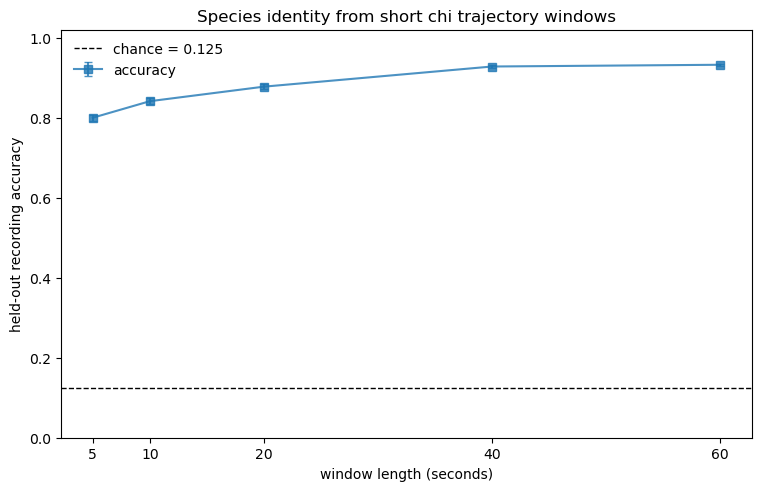

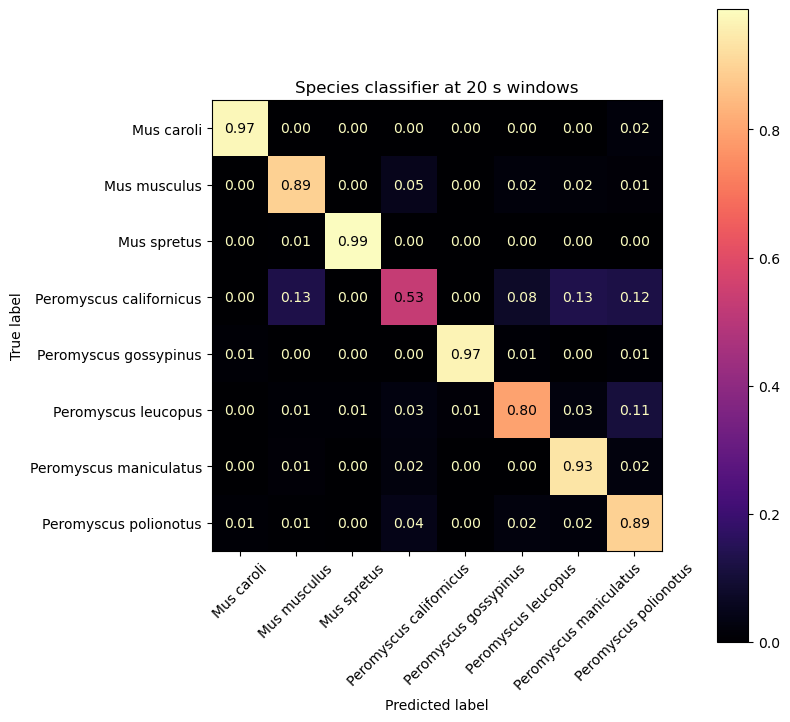

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_20s_predictions.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_20s_confusion_matrix_normalized.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_20s_confusion_matrix_normalized.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/species_chi_trajectory_classifier/setM_species_chi_trajectory_window_accuracy.png


In [23]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
summary = species_accuracy_summary.sort_values('window_seconds')
ax.errorbar(
    summary['window_seconds'],
    summary['mean_accuracy'],
    yerr=summary['sem_accuracy'].fillna(0.0),
    marker='s',
    capsize=3,
    label='accuracy',
    alpha=0.8,
)
chance = 1.0 / max(len(species_classes), 1)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'chance = {chance:.3f}')
ax.set_xticks(SPECIES_CLASSIFIER_WINDOW_SECONDS)
ax.set_xticklabels([str(int(x)) for x in SPECIES_CLASSIFIER_WINDOW_SECONDS])
ax.set_ylim(0.0, 1.02)
ax.set_xlabel('window length (seconds)')
ax.set_ylabel('held-out recording accuracy')
ax.set_title('Species identity from short chi trajectory windows')
ax.legend(frameon=False)
accuracy_png = SPECIES_CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_accuracy.png'
accuracy_pdf = SPECIES_CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_accuracy.pdf'
fig.savefig(accuracy_png, dpi=220)
fig.savefig(accuracy_pdf)
plt.show()

if target_predictions:
    target_prediction_df = pd.concat(target_predictions, ignore_index=True)
    target_prediction_path = SPECIES_CLASSIFIER_DIR / f'setM_species_{int(SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS)}s_predictions.csv'
    target_prediction_df.to_csv(target_prediction_path, index=False)
    cm = confusion_matrix(
        target_prediction_df['true_species'],
        target_prediction_df['predicted_species'],
        labels=species_classes,
        normalize='true',
    )
    cm_df = pd.DataFrame(cm, index=species_classes, columns=species_classes)
    cm_path = SPECIES_CLASSIFIER_DIR / f'setM_species_{int(SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS)}s_confusion_matrix_normalized.csv'
    cm_df.to_csv(cm_path)
    fig, ax = plt.subplots(figsize=(7.8, 7.2), constrained_layout=True)
    ConfusionMatrixDisplay(cm, display_labels=[s.replace('_', ' ') for s in species_classes]).plot(
        ax=ax,
        xticks_rotation=45,
        cmap='magma',
        colorbar=True,
        values_format='.2f',
    )
    ax.set_title(f'Species classifier at {int(SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS)} s windows')
    cm_png = SPECIES_CLASSIFIER_DIR / f'setM_species_{int(SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS)}s_confusion_matrix_normalized.png'
    cm_pdf = SPECIES_CLASSIFIER_DIR / f'setM_species_{int(SPECIES_CLASSIFIER_TARGET_WINDOW_SECONDS)}s_confusion_matrix_normalized.pdf'
    fig.savefig(cm_png, dpi=220)
    fig.savefig(cm_pdf)
    plt.show()
    print('wrote', target_prediction_path)
    print('wrote', cm_path)
    print('wrote', cm_png)

print('wrote', accuracy_png)

## Direction 1 interpretation

Direction 1 is the dominant within-species fluctuation axis in reference-aligned setM `chi` space. These plots make it interpretable by showing species positions, aligned-arm loadings, and the MoSeq syllable enrichments implied by moving along the positive versus negative end of the axis.


In [32]:
DIRECTION_INTERPRET_DIR = OUT_DIR / 'direction_1_interpretation'
DIRECTION_INTERPRET_DIR.mkdir(parents=True, exist_ok=True)
DIRECTION_INDEX = 0
DIRECTION_BOOTSTRAPS = 1000
DIRECTION_TOP_SYLLABLES = 20
DIRECTION_RNG = np.random.default_rng(SLOWMODE_RANDOM_SEED + 202)

d1 = np.asarray(within_evec[:, DIRECTION_INDEX], dtype=float)
# Fix sign for readability: positive d1 points toward the species with the largest score.
raw_scores = mean_matrix @ d1
if raw_scores[np.argmax(np.abs(raw_scores - raw_scores.mean()))] < raw_scores.mean():
    d1 = -d1

species_d1_rows = []
for species in enrichment_species_order:
    sample = sampled_states_for_species(species, SLOWMODE_STATS_FRAMES_PER_SPECIES, DIRECTION_RNG)
    frame_scores = sample @ d1
    boot_means = []
    for _ in range(DIRECTION_BOOTSTRAPS):
        idx = DIRECTION_RNG.integers(0, frame_scores.size, size=frame_scores.size)
        boot_means.append(float(frame_scores[idx].mean()))
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    species_d1_rows.append({
        'species': species,
        'genus': species.split('_')[0],
        'direction_1_score': float(frame_scores.mean()),
        'ci_low': float(ci_low),
        'ci_high': float(ci_high),
        'frame_score_sd': float(frame_scores.std()),
        'n_sampled_frames': int(frame_scores.size),
    })

species_d1_df = pd.DataFrame(species_d1_rows).sort_values('direction_1_score')
species_d1_path = DIRECTION_INTERPRET_DIR / 'setM_direction_1_species_scores_with_bootstrap_ci.csv'
species_d1_df.to_csv(species_d1_path, index=False)
display(species_d1_df)

arm_loading_df = pd.DataFrame({
    'reference_arm': [int(arm) for arm in reference_arm_order],
    'reference_arm_label': [f'reference arm {int(arm) + 1}' for arm in reference_arm_order],
    'direction_1_loading': d1,
})
arm_loading_path = DIRECTION_INTERPRET_DIR / 'setM_direction_1_reference_arm_loadings.csv'
arm_loading_df.to_csv(arm_loading_path, index=False)
display(arm_loading_df)

# Reference-species arm enrichment gives a concrete behavior dictionary for each aligned arm.
reference_enrichment = setm_enrichment_matrices[REFERENCE_SPECIES].reindex(index=reference_arm_order)
direction_behavior_vector = d1 @ reference_enrichment.to_numpy(dtype=float)

def direction_syllable_label(syllable):
    syllable_int = int(syllable)
    return syllable_label_map.get(syllable_int, str(syllable_int))

direction_behavior_df = pd.DataFrame({
    'syllable': [int(s) for s in reference_enrichment.columns],
    'syllable_label': [direction_syllable_label(s) for s in reference_enrichment.columns],
    'moseq_syllable_name': [syllable_name_map.get(int(s)) for s in reference_enrichment.columns],
    'moseq_category': [syllable_category_map.get(int(s)) for s in reference_enrichment.columns],
    'direction_1_behavior_loading': direction_behavior_vector,
})
direction_behavior_df['abs_loading'] = direction_behavior_df['direction_1_behavior_loading'].abs()
direction_behavior_path = DIRECTION_INTERPRET_DIR / 'setM_direction_1_behavior_syllable_loadings.csv'
direction_behavior_df.sort_values('direction_1_behavior_loading').to_csv(direction_behavior_path, index=False)
display(direction_behavior_df.sort_values('abs_loading', ascending=False).head(20))
print('wrote', species_d1_path)
print('wrote', arm_loading_path)
print('wrote', direction_behavior_path)


,species,genus,direction_1_score,ci_low,ci_high,frame_score_sd,n_sampled_frames
5,Peromyscus_leucopus,Peromyscus,-0.708210,-0.709888,-0.706438,0.221828,60000
4,Peromyscus_gossypinus,Peromyscus,-0.699624,-0.700700,-0.698552,0.128166,60000
2,Mus_spretus,Mus,-0.698683,-0.700100,-0.697205,0.170680,60000
3,Peromyscus_californicus,Peromyscus,-0.645500,-0.647251,-0.643799,0.225089,60000
1,Mus_musculus,Mus,-0.594492,-0.596885,-0.591973,0.292638,60000
6,Peromyscus_maniculatus,Peromyscus,-0.592882,-0.594671,-0.591044,0.227825,60000
7,Peromyscus_polionotus,Peromyscus,-0.548656,-0.550783,-0.546620,0.268412,60000
0,Mus_caroli,Mus,-0.118025,-0.119786,-0.116402,0.211832,60000


,reference_arm,reference_arm_label,direction_1_loading
0,0,reference arm 1,-0.810696
1,1,reference arm 2,0.548040
2,2,reference arm 3,0.194294
3,3,reference arm 4,0.068362


,syllable,syllable_label,moseq_syllable_name,moseq_category,direction_1_behavior_loading,abs_loading
42,42,42: groom_6,None,None,2.401422,2.401422
48,48,48: groom_11,None,None,2.031885,2.031885
46,46,46: groom_9,None,None,2.025602,2.025602
47,47,47: groom_10,None,None,1.974676,1.974676
35,35,35: groom_2,None,None,1.948352,1.948352
37,37,37: groom_4,None,None,1.924465,1.924465
36,36,36: groom_3,None,None,1.881909,1.881909
44,44,44: groom_7,None,None,1.867965,1.867965
31,31,31: groom_1,None,None,1.733158,1.733158
40,40,40: groom_5,None,None,1.651576,1.651576


wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/direction_1_interpretation/setM_direction_1_species_scores_with_bootstrap_ci.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/direction_1_interpretation/setM_direction_1_reference_arm_loadings.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/direction_1_interpretation/setM_direction_1_behavior_syllable_loadings.csv


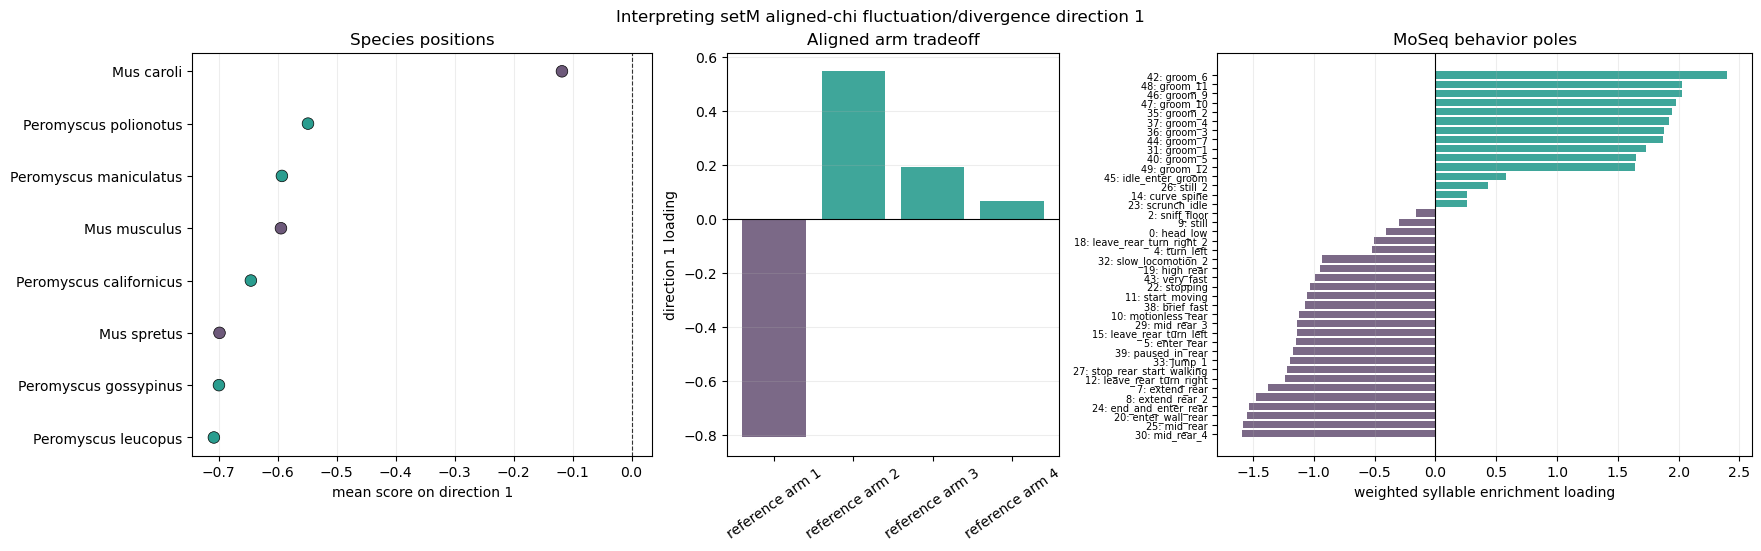

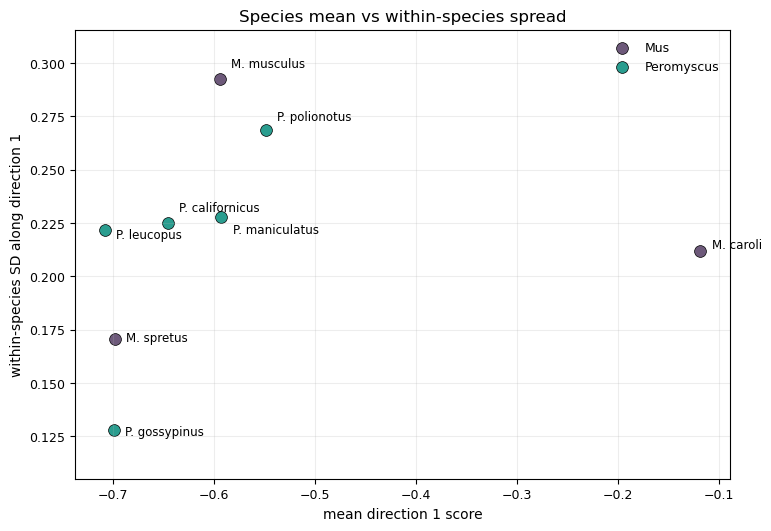

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/direction_1_interpretation/setM_direction_1_species_arm_behavior_summary.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/direction_1_interpretation/setM_direction_1_species_mean_vs_within_spread.png


In [33]:
genus_colors = {'Mus': '#6d597a', 'Peromyscus': '#2a9d8f'}

fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.4), constrained_layout=True, gridspec_kw={'width_ratios': [1.25, 0.9, 1.45]})

# Panel 1: species ordering on direction 1.
ax = axes[0]
y = np.arange(len(species_d1_df))
x = species_d1_df['direction_1_score'].to_numpy(dtype=float)
xerr = np.vstack([
    x - species_d1_df['ci_low'].to_numpy(dtype=float),
    species_d1_df['ci_high'].to_numpy(dtype=float) - x,
])
colors = [genus_colors.get(genus, '0.45') for genus in species_d1_df['genus']]
ax.errorbar(x, y, xerr=xerr, fmt='none', ecolor='0.35', elinewidth=1.2, capsize=3, zorder=1)
ax.scatter(x, y, s=70, c=colors, edgecolor='black', linewidth=0.5, zorder=2)
ax.axvline(0, color='0.2', linewidth=0.8, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels([s.replace('_', ' ') for s in species_d1_df['species']])
ax.set_xlabel('mean score on direction 1')
ax.set_title('Species positions')
ax.grid(axis='x', alpha=0.22)

# Panel 2: aligned arm loadings.
ax = axes[1]
bar_colors = np.where(arm_loading_df['direction_1_loading'] >= 0, '#2a9d8f', '#6d597a')
ax.bar(arm_loading_df['reference_arm_label'], arm_loading_df['direction_1_loading'], color=bar_colors, alpha=0.9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('direction 1 loading')
ax.set_title('Aligned arm tradeoff')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.22)

# Panel 3: behavior poles.
ax = axes[2]
top_positive = direction_behavior_df.nlargest(DIRECTION_TOP_SYLLABLES, 'direction_1_behavior_loading')
top_negative = direction_behavior_df.nsmallest(DIRECTION_TOP_SYLLABLES, 'direction_1_behavior_loading')
top_behavior = pd.concat([top_negative, top_positive], ignore_index=True).sort_values('direction_1_behavior_loading')
behavior_colors = np.where(top_behavior['direction_1_behavior_loading'] >= 0, '#2a9d8f', '#6d597a')
ax.barh(top_behavior['syllable_label'], top_behavior['direction_1_behavior_loading'], color=behavior_colors, alpha=0.9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('weighted syllable enrichment loading')
ax.set_title('MoSeq behavior poles')
ax.tick_params(axis='y', labelsize=7)
ax.grid(axis='x', alpha=0.22)

fig.suptitle('Interpreting setM aligned-chi fluctuation/divergence direction 1')
direction_summary_png = DIRECTION_INTERPRET_DIR / 'setM_direction_1_species_arm_behavior_summary.png'
direction_summary_pdf = DIRECTION_INTERPRET_DIR / 'setM_direction_1_species_arm_behavior_summary.pdf'
fig.savefig(direction_summary_png, dpi=220)
fig.savefig(direction_summary_pdf)
plt.show()

def species_short_label(species):
    genus, epithet = species.split('_', 1)
    return f'{genus[0]}. {epithet}'

spread_label_offsets = {
    'Mus_caroli': (8, 2),
    'Mus_musculus': (8, 8),
    'Mus_spretus': (8, -2),
    'Peromyscus_californicus': (8, 8),
    'Peromyscus_gossypinus': (8, -4),
    'Peromyscus_leucopus': (8, -6),
    'Peromyscus_maniculatus': (8, -12),
    'Peromyscus_polionotus': (8, 7),
}

fig, ax = plt.subplots(figsize=(7.6, 5.2), constrained_layout=True)
for genus, group in species_d1_df.groupby('genus', sort=True):
    ax.scatter(
        group['direction_1_score'],
        group['frame_score_sd'],
        s=72,
        color=genus_colors.get(genus, '0.45'),
        edgecolor='black',
        linewidth=0.5,
        label=genus,
    )
    for _, row in group.iterrows():
        ax.annotate(
            species_short_label(row['species']),
            (row['direction_1_score'], row['frame_score_sd']),
            textcoords='offset points',
            xytext=spread_label_offsets.get(row['species'], (6, 4)),
            fontsize=8.5,
        )
ax.set_xlabel('mean direction 1 score')
ax.set_ylabel('within-species SD along direction 1')
ax.set_title('Species mean vs within-species spread', fontsize=12)
ax.margins(x=0.05, y=0.14)
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.tick_params(labelsize=9)
ax.grid(alpha=0.22)
spread_png = DIRECTION_INTERPRET_DIR / 'setM_direction_1_species_mean_vs_within_spread.png'
spread_pdf = DIRECTION_INTERPRET_DIR / 'setM_direction_1_species_mean_vs_within_spread.pdf'
fig.savefig(spread_png, dpi=220)
fig.savefig(spread_pdf)
plt.show()

print('wrote', direction_summary_png)
print('wrote', spread_png)



## Whitened aligned-chi species distances

This section tests whether species structure remains after normalizing away the dominant within-species fluctuation scale. We use the pooled within-species covariance from the fluctuation-divergence section as the metric tensor, then compare species means in whitened aligned `chi` space.

Conceptually, this asks whether species means are separated by more than expected from ordinary within-species variability. A direction with large within-species variance is down-weighted; a direction with small but stable within-species variance is up-weighted. Because aligned `chi` columns are compositional, the covariance can be rank-deficient, so whitening is performed only in retained positive-variance directions.


In [26]:

WHITENED_CHI_DIR = OUT_DIR / 'whitened_aligned_chi_species_distances'
WHITENED_CHI_DIR.mkdir(parents=True, exist_ok=True)
WHITEN_RCOND = 1e-8

# Reuse the species means/covariances computed in the fluctuation-divergence section.
# If this cell is run independently after the alignment cells, rebuild them here.
if 'species_means' not in globals() or 'pooled_within_cov' not in globals() or 'mean_matrix' not in globals():
    species_means = {}
    species_covariances = {}
    for species in enrichment_species_order:
        sample = sampled_states_for_species(species, SLOWMODE_STATS_FRAMES_PER_SPECIES, SLOWMODE_RNG)
        species_means[species] = sample.mean(axis=0)
        species_covariances[species] = np.cov(sample, rowvar=False)
    mean_matrix = np.vstack([species_means[species] for species in enrichment_species_order])
    pooled_within_cov = np.mean([species_covariances[species] for species in enrichment_species_order], axis=0)
    grand_mean = mean_matrix.mean(axis=0)

whiten_eval, whiten_evec = np.linalg.eigh(pooled_within_cov)
order = np.argsort(whiten_eval)[::-1]
whiten_eval = whiten_eval[order]
whiten_evec = whiten_evec[:, order]
max_eval = float(np.max(whiten_eval))
retain_threshold = max(max_eval * WHITEN_RCOND, EPS)
retained = whiten_eval > retain_threshold

if retained.sum() == 0:
    raise ValueError('No positive-variance directions retained for whitening.')

retained_eval = whiten_eval[retained]
retained_evec = whiten_evec[:, retained]
whitened_mean_coords = (mean_matrix - grand_mean) @ retained_evec / np.sqrt(retained_eval)

raw_centered_means = mean_matrix - grand_mean
n_species = len(enrichment_species_order)
raw_mean_dist = np.zeros((n_species, n_species), dtype=float)
whitened_mean_dist = np.zeros((n_species, n_species), dtype=float)
for i in range(n_species):
    for j in range(n_species):
        raw_mean_dist[i, j] = np.linalg.norm(raw_centered_means[i] - raw_centered_means[j])
        whitened_mean_dist[i, j] = np.linalg.norm(whitened_mean_coords[i] - whitened_mean_coords[j])

raw_mean_dist_df = pd.DataFrame(raw_mean_dist, index=enrichment_species_order, columns=enrichment_species_order)
whitened_mean_dist_df = pd.DataFrame(whitened_mean_dist, index=enrichment_species_order, columns=enrichment_species_order)
whitened_coords_df = pd.DataFrame(
    whitened_mean_coords,
    index=enrichment_species_order,
    columns=[f'whitened_direction_{idx + 1}' for idx in range(whitened_mean_coords.shape[1])],
)

whiten_eigen_df = pd.DataFrame({
    'direction': np.arange(1, len(whiten_eval) + 1),
    'within_variance_eigenvalue': whiten_eval,
    'retained_for_whitening': retained,
    'within_sd': np.sqrt(np.maximum(whiten_eval, 0)),
    'precision_weight_if_retained': np.where(retained, 1 / np.sqrt(np.maximum(whiten_eval, EPS)), np.nan),
})

pairs = []
for i, species_a in enumerate(enrichment_species_order):
    for j, species_b in enumerate(enrichment_species_order):
        if j <= i:
            continue
        pairs.append({
            'species_a': species_a,
            'species_b': species_b,
            'raw_mean_euclidean_distance': raw_mean_dist[i, j],
            'whitened_mean_mahalanobis_distance': whitened_mean_dist[i, j],
            'whitened_to_raw_ratio': whitened_mean_dist[i, j] / max(raw_mean_dist[i, j], EPS),
        })
whiten_distance_pairs_df = pd.DataFrame(pairs)

raw_mean_dist_df.to_csv(WHITENED_CHI_DIR / 'setM_raw_aligned_chi_species_mean_euclidean_distance.csv')
whitened_mean_dist_df.to_csv(WHITENED_CHI_DIR / 'setM_whitened_aligned_chi_species_mean_mahalanobis_distance.csv')
whitened_coords_df.to_csv(WHITENED_CHI_DIR / 'setM_whitened_aligned_chi_species_mean_coordinates.csv')
whiten_eigen_df.to_csv(WHITENED_CHI_DIR / 'setM_aligned_chi_whitening_eigenvalues.csv', index=False)
whiten_distance_pairs_df.to_csv(WHITENED_CHI_DIR / 'setM_raw_vs_whitened_species_mean_distance_pairs.csv', index=False)

display(whiten_eigen_df)
display(whitened_mean_dist_df.round(3))
display(whiten_distance_pairs_df.sort_values('whitened_mean_mahalanobis_distance').head(12))
print('retained whitening directions:', int(retained.sum()), 'of', len(retained))
print('wrote', WHITENED_CHI_DIR)


,direction,within_variance_eigenvalue,retained_for_whitening,within_sd,precision_weight_if_retained
0,1,5.014100e-02,True,2.239219e-01,4.465843
1,2,7.305585e-03,True,8.547271e-02,11.699640
2,3,2.335058e-03,True,4.832244e-02,20.694319
3,4,6.098637e-18,False,2.469542e-09,NaN


,Mus_caroli,Mus_musculus,Mus_spretus,Peromyscus_californicus,Peromyscus_gossypinus,Peromyscus_leucopus,Peromyscus_maniculatus,Peromyscus_polionotus
Mus_caroli,0.000,2.424,2.608,2.624,3.332,2.785,2.508,2.210
Mus_musculus,2.424,0.000,1.488,0.277,2.286,0.829,0.214,0.452
Mus_spretus,2.608,1.488,0.000,1.448,2.218,1.165,1.687,1.539
Peromyscus_californicus,2.624,0.277,1.448,0.000,2.098,0.605,0.326,0.502
Peromyscus_gossypinus,3.332,2.286,2.218,2.098,0.000,1.615,2.299,1.969
Peromyscus_leucopus,2.785,0.829,1.165,0.605,1.615,0.000,0.911,0.795
Peromyscus_maniculatus,2.508,0.214,1.687,0.326,2.299,0.911,0.000,0.471
Peromyscus_polionotus,2.210,0.452,1.539,0.502,1.969,0.795,0.471,0.000


,species_a,species_b,raw_mean_euclidean_distance,whitened_mean_mahalanobis_distance,whitened_to_raw_ratio
11,Mus_musculus,Peromyscus_maniculatus,0.018098,0.214089,11.829322
8,Mus_musculus,Peromyscus_californicus,0.050227,0.276812,5.511175
20,Peromyscus_californicus,Peromyscus_maniculatus,0.056770,0.326036,5.743127
12,Mus_musculus,Peromyscus_polionotus,0.053412,0.452360,8.469328
27,Peromyscus_maniculatus,Peromyscus_polionotus,0.053511,0.471088,8.803633
21,Peromyscus_californicus,Peromyscus_polionotus,0.099972,0.501938,5.020769
19,Peromyscus_californicus,Peromyscus_leucopus,0.072734,0.604925,8.316961
26,Peromyscus_leucopus,Peromyscus_polionotus,0.163605,0.794523,4.856348
10,Mus_musculus,Peromyscus_leucopus,0.119434,0.829243,6.943082
25,Peromyscus_leucopus,Peromyscus_maniculatus,0.128535,0.911053,7.087982


retained whitening directions: 3 of 4
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/whitened_aligned_chi_species_distances


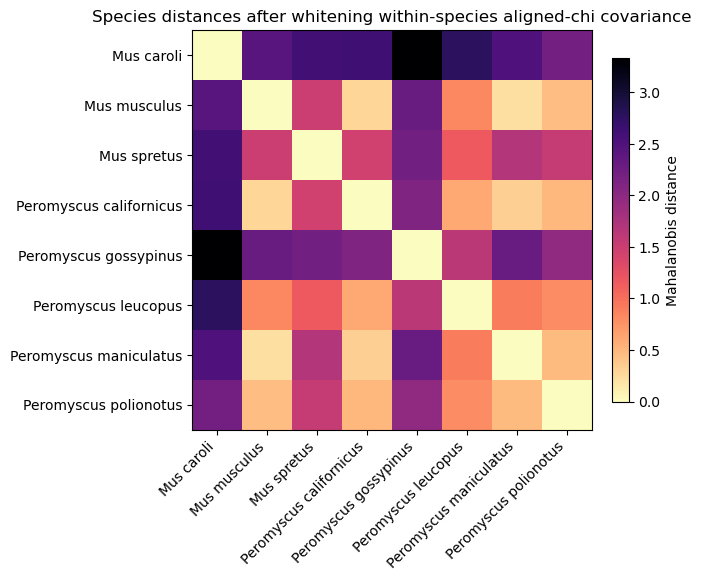

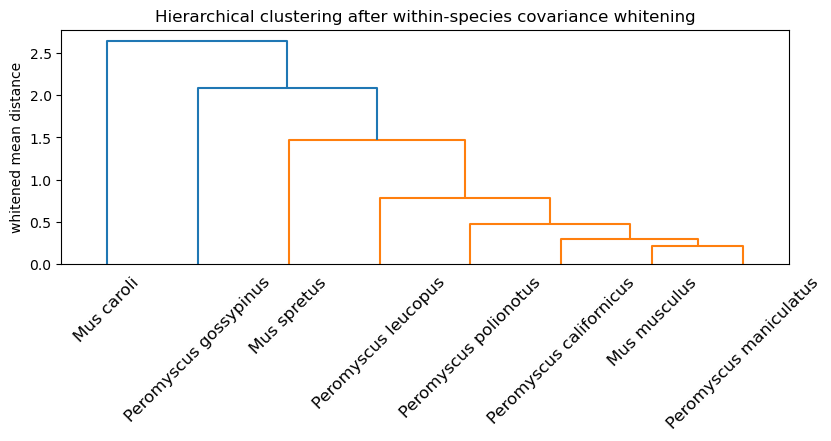

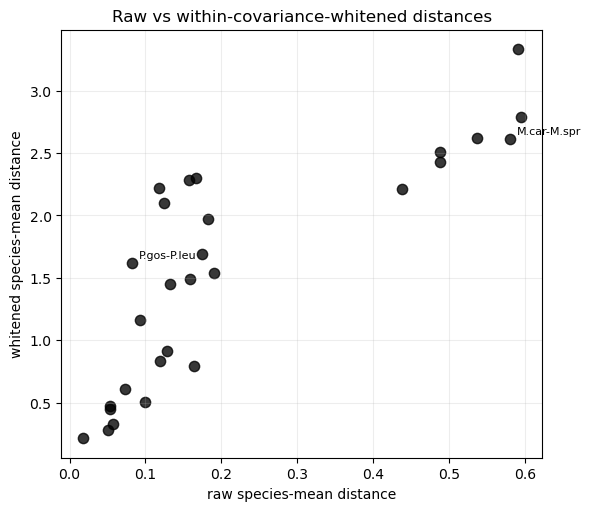

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/whitened_aligned_chi_species_distances/setM_whitened_aligned_chi_species_mean_distance_matrix.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/whitened_aligned_chi_species_distances/setM_whitened_aligned_chi_species_mean_tree.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/whitened_aligned_chi_species_distances/setM_raw_vs_whitened_aligned_chi_species_mean_distances.png


In [27]:

def plot_square_distance(distance_df, title, cbar_label='distance', cmap='magma_r'):
    fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
    im = ax.imshow(distance_df.to_numpy(dtype=float), cmap=cmap)
    ax.set_xticks(np.arange(distance_df.shape[1]))
    ax.set_xticklabels([s.replace('_', ' ') for s in distance_df.columns], rotation=45, ha='right')
    ax.set_yticks(np.arange(distance_df.shape[0]))
    ax.set_yticklabels([s.replace('_', ' ') for s in distance_df.index])
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label(cbar_label)
    return fig, ax

fig, ax = plot_square_distance(
    whitened_mean_dist_df,
    'Species distances after whitening within-species aligned-chi covariance',
    cbar_label='Mahalanobis distance',
)
whitened_matrix_png = WHITENED_CHI_DIR / 'setM_whitened_aligned_chi_species_mean_distance_matrix.png'
whitened_matrix_pdf = WHITENED_CHI_DIR / 'setM_whitened_aligned_chi_species_mean_distance_matrix.pdf'
fig.savefig(whitened_matrix_png, dpi=220)
fig.savefig(whitened_matrix_pdf)
plt.show()

condensed = squareform(whitened_mean_dist_df.to_numpy(dtype=float), checks=False)
Z = linkage(condensed, method='average')
fig, ax = plt.subplots(figsize=(8.2, 4.3), constrained_layout=True)
dendrogram(Z, labels=[s.replace('_', ' ') for s in enrichment_species_order], leaf_rotation=45, ax=ax)
ax.set_ylabel('whitened mean distance')
ax.set_title('Hierarchical clustering after within-species covariance whitening')
whitened_tree_png = WHITENED_CHI_DIR / 'setM_whitened_aligned_chi_species_mean_tree.png'
whitened_tree_pdf = WHITENED_CHI_DIR / 'setM_whitened_aligned_chi_species_mean_tree.pdf'
fig.savefig(whitened_tree_png, dpi=220)
fig.savefig(whitened_tree_pdf)
plt.show()

fig, ax = plt.subplots(figsize=(5.8, 5.0), constrained_layout=True)
ax.scatter(
    whiten_distance_pairs_df['raw_mean_euclidean_distance'],
    whiten_distance_pairs_df['whitened_mean_mahalanobis_distance'],
    s=55,
    color='black',
    alpha=0.78,
)
for _, row in whiten_distance_pairs_df.iterrows():
    if row['whitened_to_raw_ratio'] == whiten_distance_pairs_df['whitened_to_raw_ratio'].max() or row['whitened_to_raw_ratio'] == whiten_distance_pairs_df['whitened_to_raw_ratio'].min():
        label = f"{row['species_a'].split('_')[0][0]}.{row['species_a'].split('_')[1][:3]}-{row['species_b'].split('_')[0][0]}.{row['species_b'].split('_')[1][:3]}"
        ax.annotate(label, (row['raw_mean_euclidean_distance'], row['whitened_mean_mahalanobis_distance']), textcoords='offset points', xytext=(5, 4), fontsize=8)
ax.set_xlabel('raw species-mean distance')
ax.set_ylabel('whitened species-mean distance')
ax.set_title('Raw vs within-covariance-whitened distances')
ax.grid(alpha=0.22)
raw_vs_whitened_png = WHITENED_CHI_DIR / 'setM_raw_vs_whitened_aligned_chi_species_mean_distances.png'
raw_vs_whitened_pdf = WHITENED_CHI_DIR / 'setM_raw_vs_whitened_aligned_chi_species_mean_distances.pdf'
fig.savefig(raw_vs_whitened_png, dpi=220)
fig.savefig(raw_vs_whitened_pdf)
plt.show()

print('wrote', whitened_matrix_png)
print('wrote', whitened_tree_png)
print('wrote', raw_vs_whitened_png)



## Fluctuation-dissipation alignment null test

This formalizes the fluctuation-divergence idea: do the directions animals explore within species predict the directions along which species means diverge?

The observed statistic is the correlation between log within-species variance and log between-species divergence across retained within-covariance eigen-directions. The null keeps the within-species fluctuation spectrum and the between-species divergence spectrum fixed, but randomly rotates the between-species covariance relative to the within-species eigenbasis. If the observed statistic is unusually high under this rotation null, then between-species divergence is preferentially aligned to the within-species fluctuation geometry rather than simply having some arbitrary covariance structure.


In [28]:

FLUCT_DISS_DIR = OUT_DIR / 'fluctuation_dissipation_alignment_test'
FLUCT_DISS_DIR.mkdir(parents=True, exist_ok=True)
FLUCT_DISS_N_ROTATIONS = 20000
FLUCT_DISS_RNG = np.random.default_rng(SLOWMODE_RANDOM_SEED + 404)
FLUCT_DISS_RCOND = 1e-8

# Rebuild the core covariance objects if this cell is run out of order.
if 'species_means' not in globals() or 'pooled_within_cov' not in globals() or 'between_cov' not in globals():
    species_means = {}
    species_covariances = {}
    for species in enrichment_species_order:
        sample = sampled_states_for_species(species, SLOWMODE_STATS_FRAMES_PER_SPECIES, SLOWMODE_RNG)
        species_means[species] = sample.mean(axis=0)
        species_covariances[species] = np.cov(sample, rowvar=False)
    mean_matrix = np.vstack([species_means[species] for species in enrichment_species_order])
    pooled_within_cov = np.mean([species_covariances[species] for species in enrichment_species_order], axis=0)
    grand_mean = mean_matrix.mean(axis=0)
    between_cov = np.cov(mean_matrix, rowvar=False)

align_eval, align_evec = np.linalg.eigh(pooled_within_cov)
order = np.argsort(align_eval)[::-1]
align_eval = align_eval[order]
align_evec = align_evec[:, order]
retain_threshold = max(float(align_eval.max()) * FLUCT_DISS_RCOND, EPS)
align_retained = align_eval > retain_threshold

within_variance_obs = align_eval[align_retained]
E = align_evec[:, align_retained]
between_in_within_basis = E.T @ between_cov @ E
between_divergence_obs = np.diag(between_in_within_basis).copy()

log_within_obs = np.log10(within_variance_obs + EPS)
log_between_obs = np.log10(between_divergence_obs + EPS)
observed_log_pearson = float(np.corrcoef(log_within_obs, log_between_obs)[0, 1]) if len(log_within_obs) > 1 else np.nan
observed_top_share = float(between_divergence_obs[0] / max(between_divergence_obs.sum(), EPS))
observed_slope = float(np.polyfit(log_within_obs, log_between_obs, 1)[0]) if len(log_within_obs) > 1 else np.nan

# Rotation null: preserve between-covariance eigenvalues in retained subspace, randomize orientation.
between_eval_retained = np.linalg.eigvalsh(between_in_within_basis)
null_rows = []
for rotation_idx in range(FLUCT_DISS_N_ROTATIONS):
    random_matrix = FLUCT_DISS_RNG.normal(size=(len(within_variance_obs), len(within_variance_obs)))
    q, r = np.linalg.qr(random_matrix)
    signs = np.sign(np.diag(r))
    signs[signs == 0] = 1
    q = q * signs
    rotated_between = q @ np.diag(between_eval_retained) @ q.T
    null_between_diag = np.clip(np.diag(rotated_between), 0, None)
    null_log_between = np.log10(null_between_diag + EPS)
    null_log_pearson = float(np.corrcoef(log_within_obs, null_log_between)[0, 1]) if len(log_within_obs) > 1 else np.nan
    null_slope = float(np.polyfit(log_within_obs, null_log_between, 1)[0]) if len(log_within_obs) > 1 else np.nan
    null_top_share = float(null_between_diag[0] / max(null_between_diag.sum(), EPS))
    null_rows.append({
        'rotation': rotation_idx,
        'log_pearson': null_log_pearson,
        'log_slope': null_slope,
        'top_within_direction_between_divergence_share': null_top_share,
    })

null_df = pd.DataFrame(null_rows)
observed_df = pd.DataFrame({
    'direction': np.arange(1, len(within_variance_obs) + 1),
    'within_variance': within_variance_obs,
    'between_species_divergence': between_divergence_obs,
    'log10_within_variance': log_within_obs,
    'log10_between_species_divergence': log_between_obs,
    'between_divergence_share': between_divergence_obs / max(between_divergence_obs.sum(), EPS),
})

def upper_tail_p(null_values, observed_value):
    null_values = np.asarray(null_values, dtype=float)
    return float((np.sum(null_values >= observed_value) + 1) / (np.sum(np.isfinite(null_values)) + 1))

summary_df = pd.DataFrame([{
    'n_retained_directions': int(len(within_variance_obs)),
    'n_rotation_nulls': int(FLUCT_DISS_N_ROTATIONS),
    'observed_log_pearson': observed_log_pearson,
    'rotation_null_p_log_pearson_upper_tail': upper_tail_p(null_df['log_pearson'], observed_log_pearson),
    'observed_log_slope': observed_slope,
    'rotation_null_p_log_slope_upper_tail': upper_tail_p(null_df['log_slope'], observed_slope),
    'observed_top_within_direction_between_divergence_share': observed_top_share,
    'rotation_null_p_top_share_upper_tail': upper_tail_p(null_df['top_within_direction_between_divergence_share'], observed_top_share),
}])

observed_df.to_csv(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_observed_directions.csv', index=False)
null_df.to_csv(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_rotation_null.csv', index=False)
summary_df.to_csv(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_alignment_summary.csv', index=False)

display(observed_df)
display(summary_df)
print('wrote', FLUCT_DISS_DIR)


,direction,within_variance,between_species_divergence,log10_within_variance,log10_between_species_divergence,between_divergence_share
0,1,0.050141,0.037741,-1.299807,-1.423182,0.909666
1,2,0.007306,0.002563,-2.136345,-2.591279,0.061771
2,3,0.002335,0.001185,-2.631702,-2.926255,0.028563


,n_retained_directions,n_rotation_nulls,observed_log_pearson,rotation_null_p_log_pearson_upper_tail,observed_log_slope,rotation_null_p_log_slope_upper_tail,observed_top_within_direction_between_divergence_share,rotation_null_p_top_share_upper_tail
0,3,20000,0.986764,0.049498,1.156634,0.00175,0.909666,0.0041


wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/fluctuation_dissipation_alignment_test


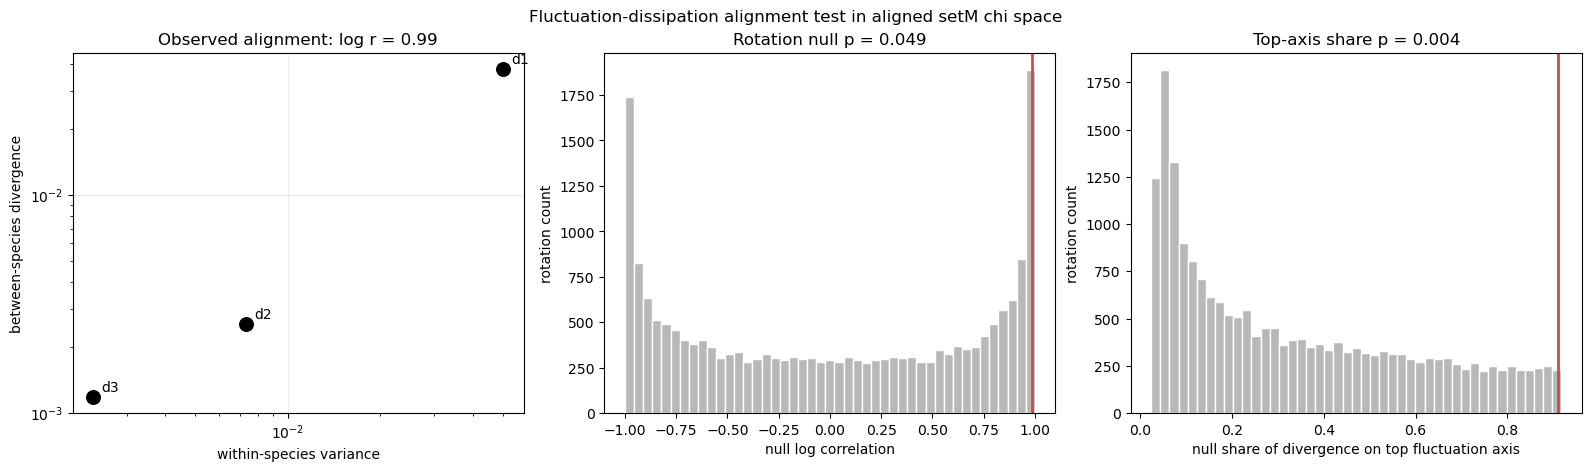

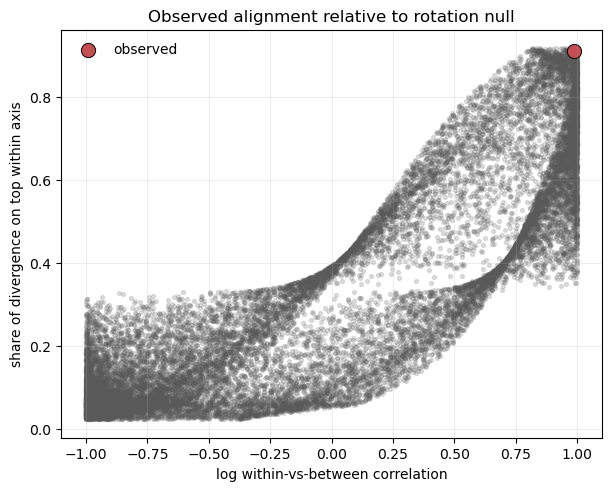

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/fluctuation_dissipation_alignment_test/setM_fluctuation_dissipation_alignment_rotation_null.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/fluctuation_dissipation_alignment_test/setM_fluctuation_dissipation_joint_null_position.png


In [29]:

fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.6), constrained_layout=True)

ax = axes[0]
ax.scatter(
    observed_df['within_variance'],
    observed_df['between_species_divergence'],
    s=95,
    color='black',
    zorder=2,
)
for _, row in observed_df.iterrows():
    ax.annotate(f"d{int(row['direction'])}", (row['within_variance'], row['between_species_divergence']), textcoords='offset points', xytext=(6, 4))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('within-species variance')
ax.set_ylabel('between-species divergence')
ax.set_title(f"Observed alignment: log r = {summary_df.loc[0, 'observed_log_pearson']:.2f}")
ax.grid(alpha=0.22)

ax = axes[1]
ax.hist(null_df['log_pearson'], bins=45, color='0.72', edgecolor='white')
ax.axvline(summary_df.loc[0, 'observed_log_pearson'], color='#c44e52', linewidth=2)
ax.set_xlabel('null log correlation')
ax.set_ylabel('rotation count')
ax.set_title(f"Rotation null p = {summary_df.loc[0, 'rotation_null_p_log_pearson_upper_tail']:.3f}")

ax = axes[2]
ax.hist(null_df['top_within_direction_between_divergence_share'], bins=45, color='0.72', edgecolor='white')
ax.axvline(summary_df.loc[0, 'observed_top_within_direction_between_divergence_share'], color='#c44e52', linewidth=2)
ax.set_xlabel('null share of divergence on top fluctuation axis')
ax.set_ylabel('rotation count')
ax.set_title(f"Top-axis share p = {summary_df.loc[0, 'rotation_null_p_top_share_upper_tail']:.3f}")

fig.suptitle('Fluctuation-dissipation alignment test in aligned setM chi space')
fluct_diss_png = FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_alignment_rotation_null.png'
fluct_diss_pdf = FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_alignment_rotation_null.pdf'
fig.savefig(fluct_diss_png, dpi=220)
fig.savefig(fluct_diss_pdf)
plt.show()

fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)
ax.scatter(null_df['log_pearson'], null_df['top_within_direction_between_divergence_share'], s=8, alpha=0.18, color='0.35')
ax.scatter(
    [summary_df.loc[0, 'observed_log_pearson']],
    [summary_df.loc[0, 'observed_top_within_direction_between_divergence_share']],
    s=105,
    color='#c44e52',
    edgecolor='black',
    linewidth=0.7,
    label='observed',
)
ax.set_xlabel('log within-vs-between correlation')
ax.set_ylabel('share of divergence on top within axis')
ax.set_title('Observed alignment relative to rotation null')
ax.legend(frameon=False)
ax.grid(alpha=0.22)
fluct_diss_joint_png = FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_joint_null_position.png'
fluct_diss_joint_pdf = FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_joint_null_position.pdf'
fig.savefig(fluct_diss_joint_png, dpi=220)
fig.savefig(fluct_diss_joint_pdf)
plt.show()

print('wrote', fluct_diss_png)
print('wrote', fluct_diss_joint_png)



## Aligned-arm occupancy and trajectory simulations

These plots make the setM arms more tangible. The occupancy plots summarize how much time each species spends in each reference-aligned arm, using both soft `chi` mass and hard `argmax(chi)` arm labels. The trajectory strips show short real snippets and simple Markov-chain simulations through the aligned arms, where each species' transition matrix is estimated from its observed frame-to-frame hard-arm sequence.


In [35]:

ARM_TRAJECTORY_DIR = OUT_DIR / 'aligned_arm_occupancy_trajectories'
ARM_TRAJECTORY_DIR.mkdir(parents=True, exist_ok=True)
ARM_TRAJ_RNG = np.random.default_rng(SLOWMODE_RANDOM_SEED + 606)
ARM_TRAJECTORY_LENGTH = 9000
ARM_TRAJECTORY_DT_SECONDS = 1 / SLOWMODE_FS
ARM_TRAJECTORY_PLOT_STEP = 3
ARM_TRAJECTORY_TRANSITION_STRIDE = max(1, int(round(0.25 * SLOWMODE_FS)))

arm_palette = np.array(['#6d597a', '#2a9d8f', '#e9c46a', '#e76f51'])
arm_labels = [f'arm {idx + 1}' for idx in range(len(reference_arm_order))]


def valid_states_from_file(path, n_states):
    states = np.asarray(np.load(path, mmap_mode='r')).reshape(-1)
    valid = np.isfinite(states)
    states = states[valid].astype(int, copy=False)
    return states[(states >= 0) & (states < n_states)]


def aligned_hard_arm_lookup(species):
    chi = aligned_chi_for_species(species)
    return np.argmax(chi, axis=1).astype(int)


def summarize_species_arm_occupancy(species):
    chi = aligned_chi_for_species(species)
    hard_lookup = aligned_hard_arm_lookup(species)
    soft_sum = np.zeros(len(reference_arm_order), dtype=float)
    hard_counts = np.zeros(len(reference_arm_order), dtype=float)
    transition_counts = np.zeros((len(reference_arm_order), len(reference_arm_order)), dtype=float)
    dwell_lengths = []
    total_frames = 0
    n_files = 0
    example_sequences = []

    for path in state_files_for_species(species):
        states = valid_states_from_file(path, chi.shape[0])
        if states.size == 0:
            continue
        n_files += 1
        total_frames += int(states.size)
        soft_sum += chi[states].sum(axis=0)
        hard_sequence = hard_lookup[states]
        hard_counts += np.bincount(hard_sequence, minlength=len(reference_arm_order))

        if hard_sequence.size > ARM_TRAJECTORY_TRANSITION_STRIDE:
            src = hard_sequence[:-ARM_TRAJECTORY_TRANSITION_STRIDE]
            dst = hard_sequence[ARM_TRAJECTORY_TRANSITION_STRIDE:]
            np.add.at(transition_counts, (src, dst), 1)

        change_idx = np.flatnonzero(np.diff(hard_sequence) != 0) + 1
        starts = np.r_[0, change_idx]
        ends = np.r_[change_idx, hard_sequence.size]
        dwell_lengths.extend((ends - starts).tolist())

        if hard_sequence.size >= ARM_TRAJECTORY_LENGTH:
            start = ARM_TRAJ_RNG.integers(0, hard_sequence.size - ARM_TRAJECTORY_LENGTH + 1)
            example_sequences.append(hard_sequence[start:start + ARM_TRAJECTORY_LENGTH])

    if total_frames == 0:
        raise RuntimeError(f'No valid states found for {species}')

    transition_probs = transition_counts / np.maximum(transition_counts.sum(axis=1, keepdims=True), EPS)
    empty_rows = transition_counts.sum(axis=1) == 0
    transition_probs[empty_rows] = hard_counts / max(hard_counts.sum(), EPS)

    return {
        'species': species,
        'n_state_files': n_files,
        'total_frames': total_frames,
        'soft_fraction': soft_sum / max(soft_sum.sum(), EPS),
        'hard_fraction': hard_counts / max(hard_counts.sum(), EPS),
        'transition_counts': transition_counts,
        'transition_probs': transition_probs,
        'median_dwell_seconds': float(np.median(dwell_lengths) / SLOWMODE_FS) if dwell_lengths else np.nan,
        'mean_dwell_seconds': float(np.mean(dwell_lengths) / SLOWMODE_FS) if dwell_lengths else np.nan,
        'example_sequence': example_sequences[0] if example_sequences else None,
    }


def simulate_arm_sequence(initial_probs, transition_probs, n_steps, rng):
    sequence = np.empty(n_steps, dtype=int)
    sequence[0] = rng.choice(len(initial_probs), p=initial_probs / np.maximum(initial_probs.sum(), EPS))
    for idx in range(1, n_steps):
        p = transition_probs[sequence[idx - 1]]
        sequence[idx] = rng.choice(len(p), p=p / np.maximum(p.sum(), EPS))
    return sequence

arm_summaries = {species: summarize_species_arm_occupancy(species) for species in enrichment_species_order}

occupancy_rows = []
transition_rows = []
dwell_rows = []
for species, summary in arm_summaries.items():
    dwell_rows.append({
        'species': species,
        'n_state_files': summary['n_state_files'],
        'total_frames': summary['total_frames'],
        'median_dwell_seconds': summary['median_dwell_seconds'],
        'mean_dwell_seconds': summary['mean_dwell_seconds'],
    })
    for arm_idx, reference_arm in enumerate(reference_arm_order):
        occupancy_rows.append({
            'species': species,
            'reference_arm': int(reference_arm),
            'reference_arm_label': arm_labels[arm_idx],
            'soft_chi_fraction': summary['soft_fraction'][arm_idx],
            'hard_argmax_fraction': summary['hard_fraction'][arm_idx],
            'n_state_files': summary['n_state_files'],
            'total_frames': summary['total_frames'],
        })
        for dst_idx, dst_reference_arm in enumerate(reference_arm_order):
            transition_rows.append({
                'species': species,
                'source_reference_arm': int(reference_arm),
                'target_reference_arm': int(dst_reference_arm),
                'source_reference_arm_label': arm_labels[arm_idx],
                'target_reference_arm_label': arm_labels[dst_idx],
                'transition_probability': summary['transition_probs'][arm_idx, dst_idx],
                'transition_count': summary['transition_counts'][arm_idx, dst_idx],
                'transition_stride_frames': ARM_TRAJECTORY_TRANSITION_STRIDE,
                'transition_stride_seconds': ARM_TRAJECTORY_TRANSITION_STRIDE / SLOWMODE_FS,
            })

arm_occupancy_df = pd.DataFrame(occupancy_rows)
arm_transition_df = pd.DataFrame(transition_rows)
arm_dwell_df = pd.DataFrame(dwell_rows)

arm_occupancy_path = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_occupancy_by_species.csv'
arm_transition_path = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_transition_probabilities_by_species.csv'
arm_dwell_path = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_dwell_summary_by_species.csv'
arm_occupancy_df.to_csv(arm_occupancy_path, index=False)
arm_transition_df.to_csv(arm_transition_path, index=False)
arm_dwell_df.to_csv(arm_dwell_path, index=False)

display(arm_occupancy_df.head(12))
display(arm_dwell_df)
print('wrote', arm_occupancy_path)
print('wrote', arm_transition_path)
print('wrote', arm_dwell_path)


,species,reference_arm,reference_arm_label,soft_chi_fraction,hard_argmax_fraction,n_state_files,total_frames
0,Mus_caroli,0,arm 1,0.426673,0.522230,15,9288209
1,Mus_caroli,1,arm 2,0.340326,0.453537,15,9288209
2,Mus_caroli,2,arm 3,0.188722,0.020199,15,9288209
3,Mus_caroli,3,arm 4,0.044279,0.004034,15,9288209
4,Mus_musculus,0,arm 1,0.835681,0.899100,93,85753806
5,Mus_musculus,1,arm 2,0.138214,0.096181,93,85753806
6,Mus_musculus,2,arm 3,0.022687,0.003353,93,85753806
7,Mus_musculus,3,arm 4,0.003417,0.001366,93,85753806
8,Mus_spretus,0,arm 1,0.890124,0.953465,39,14904006
9,Mus_spretus,1,arm 2,0.009623,0.001018,39,14904006


,species,n_state_files,total_frames,median_dwell_seconds,mean_dwell_seconds
0,Mus_caroli,15,9288209,0.200000,0.775833
1,Mus_musculus,93,85753806,0.408333,5.996048
2,Mus_spretus,39,14904006,0.366667,3.827664
3,Peromyscus_californicus,23,5183742,0.416667,11.022672
4,Peromyscus_gossypinus,20,4319780,0.333333,53.728607
5,Peromyscus_leucopus,14,3023846,0.266667,25.376351
6,Peromyscus_maniculatus,129,31750491,0.325000,7.093687
7,Peromyscus_polionotus,44,10583491,0.333333,4.195802


wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/aligned_arm_occupancy_trajectories/setM_aligned_arm_occupancy_by_species.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/aligned_arm_occupancy_trajectories/setM_aligned_arm_transition_probabilities_by_species.csv
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/aligned_arm_occupancy_trajectories/setM_aligned_arm_dwell_summary_by_species.csv


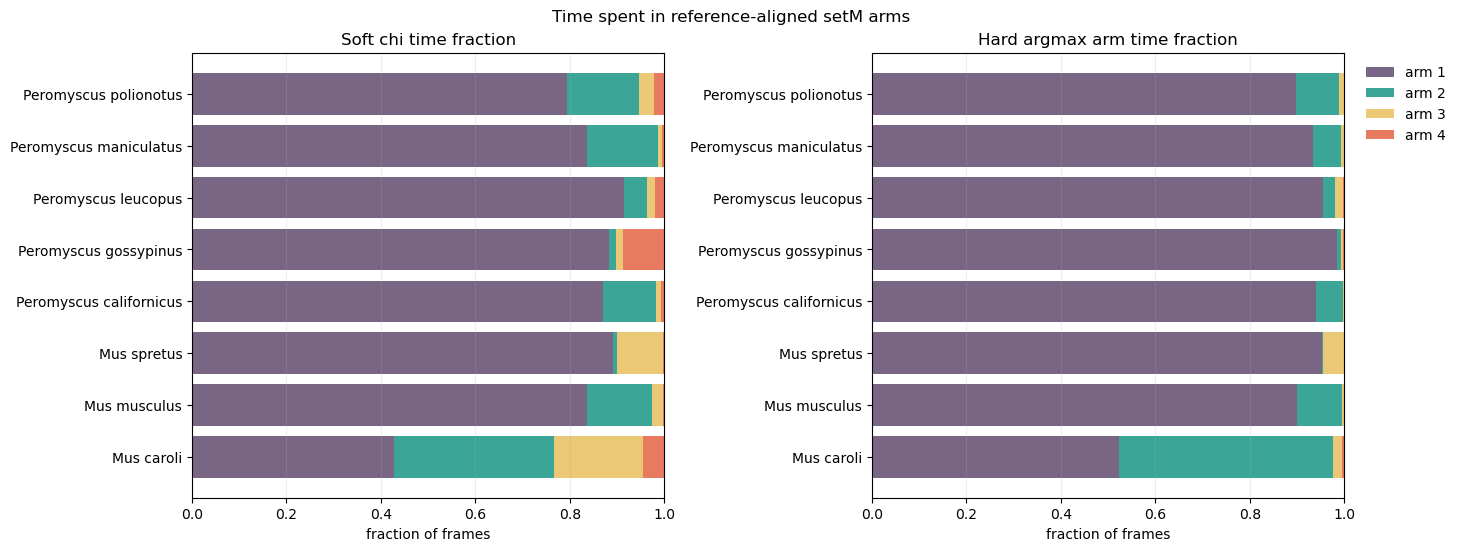

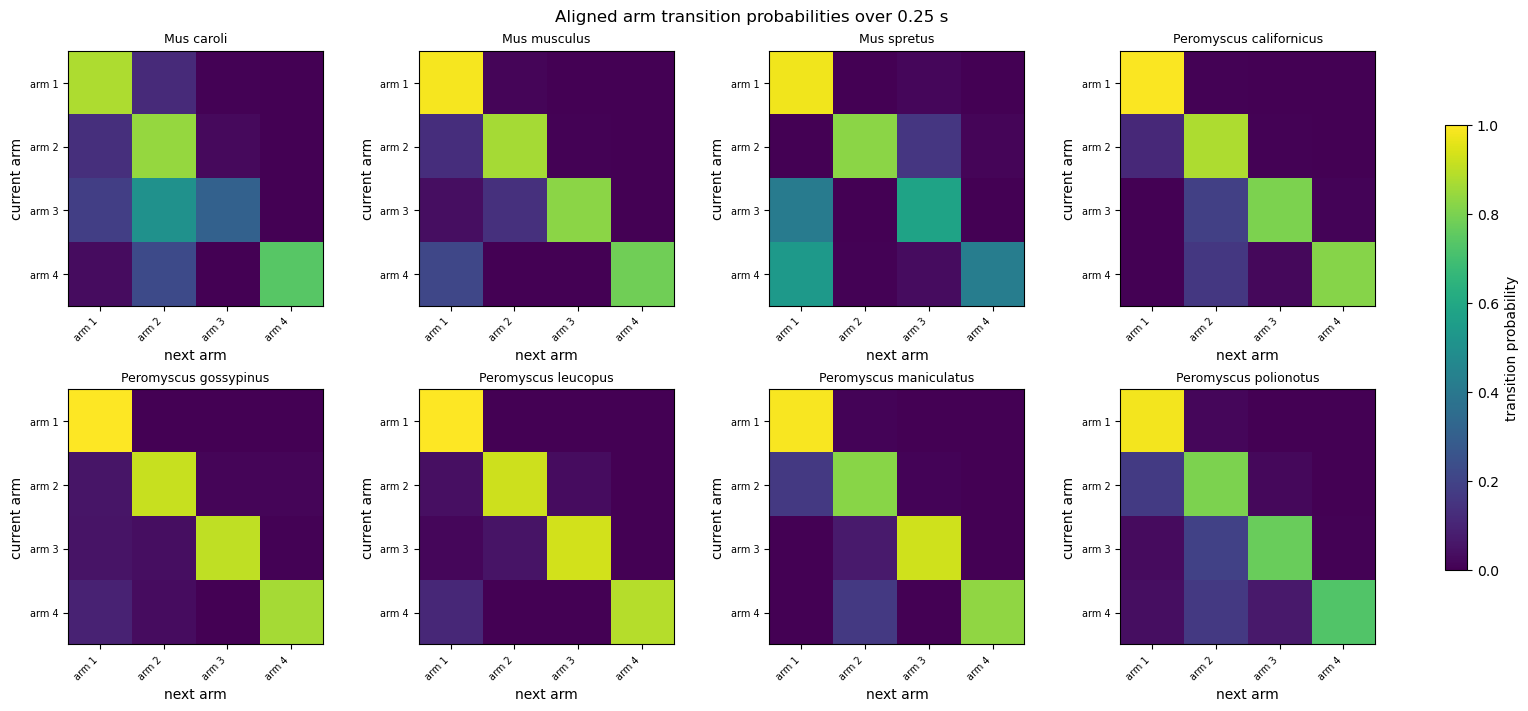

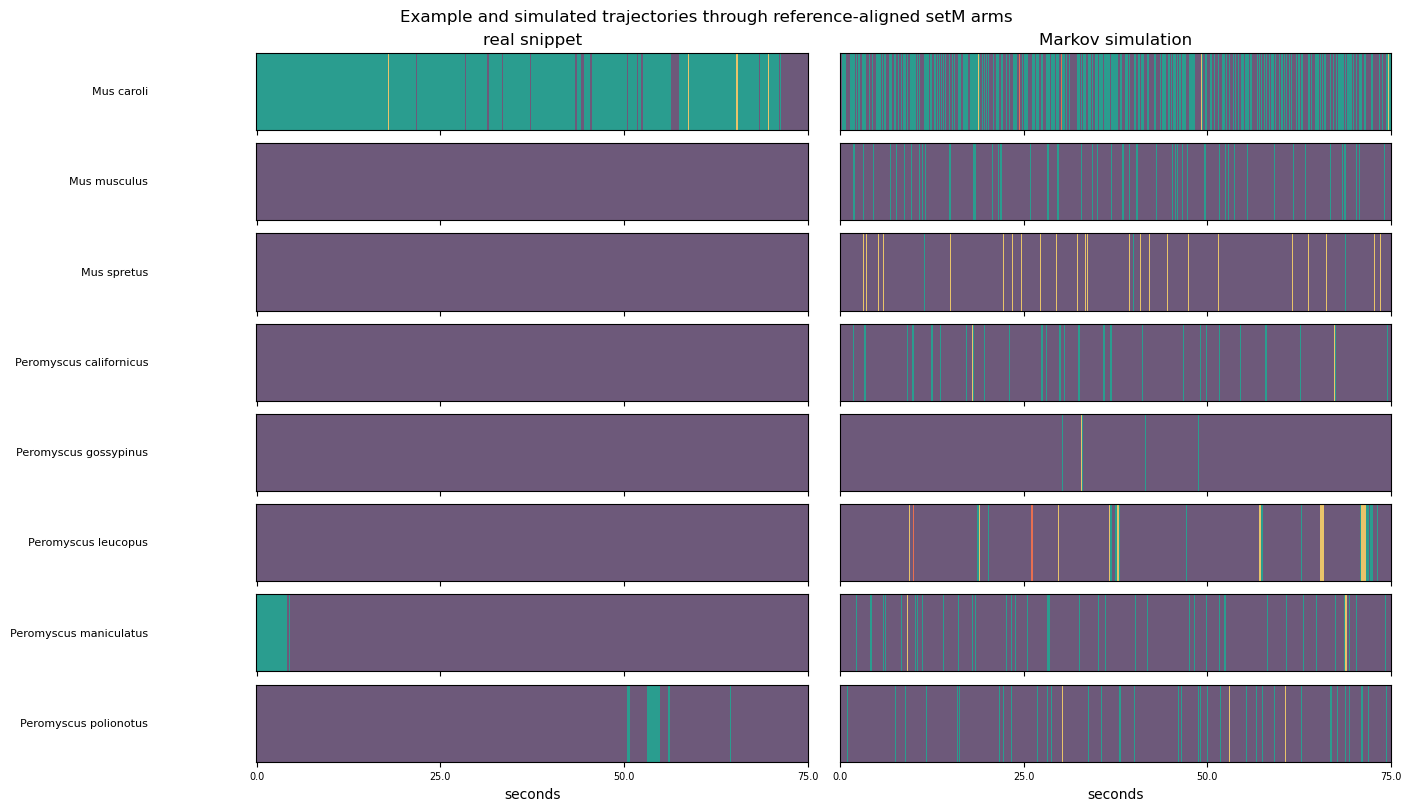

wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/aligned_arm_occupancy_trajectories/setM_aligned_arm_time_fraction_by_species.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/aligned_arm_occupancy_trajectories/setM_aligned_arm_transition_matrices_by_species.png
wrote /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo/aligned_arm_occupancy_trajectories/setM_aligned_arm_real_and_simulated_trajectory_strips.png


In [36]:

soft_matrix = (
    arm_occupancy_df
    .pivot(index='species', columns='reference_arm_label', values='soft_chi_fraction')
    .loc[enrichment_species_order, arm_labels]
)
hard_matrix = (
    arm_occupancy_df
    .pivot(index='species', columns='reference_arm_label', values='hard_argmax_fraction')
    .loc[enrichment_species_order, arm_labels]
)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), constrained_layout=True)
for ax, matrix, title in [
    (axes[0], soft_matrix, 'Soft chi time fraction'),
    (axes[1], hard_matrix, 'Hard argmax arm time fraction'),
]:
    bottom = np.zeros(matrix.shape[0])
    y = np.arange(matrix.shape[0])
    for arm_idx, arm_label in enumerate(matrix.columns):
        values = matrix[arm_label].to_numpy(dtype=float)
        ax.barh(y, values, left=bottom, color=arm_palette[arm_idx], label=arm_label, alpha=0.92)
        bottom += values
    ax.set_yticks(y)
    ax.set_yticklabels([s.replace('_', ' ') for s in matrix.index])
    ax.set_xlim(0, 1)
    ax.set_xlabel('fraction of frames')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.22)
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('Time spent in reference-aligned setM arms')
occupancy_png = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_time_fraction_by_species.png'
occupancy_pdf = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_time_fraction_by_species.pdf'
fig.savefig(occupancy_png, dpi=220)
fig.savefig(occupancy_pdf)
plt.show()

fig, axes = plt.subplots(2, int(np.ceil(len(enrichment_species_order) / 2)), figsize=(15.5, 7.0), constrained_layout=True, squeeze=False)
for ax, species in zip(axes.flat, enrichment_species_order):
    probs = arm_summaries[species]['transition_probs']
    im = ax.imshow(probs, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(species.replace('_', ' '), fontsize=9)
    ax.set_xticks(range(len(arm_labels)))
    ax.set_xticklabels(arm_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(arm_labels)))
    ax.set_yticklabels(arm_labels, fontsize=7)
    ax.set_xlabel('next arm')
    ax.set_ylabel('current arm')
for ax in axes.flat[len(enrichment_species_order):]:
    ax.set_visible(False)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label='transition probability')
fig.suptitle(f'Aligned arm transition probabilities over {ARM_TRAJECTORY_TRANSITION_STRIDE / SLOWMODE_FS:.2f} s')
transition_png = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_transition_matrices_by_species.png'
transition_pdf = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_transition_matrices_by_species.pdf'
fig.savefig(transition_png, dpi=220)
fig.savefig(transition_pdf)
plt.show()

plot_steps = np.arange(0, ARM_TRAJECTORY_LENGTH, ARM_TRAJECTORY_PLOT_STEP)
time_axis = plot_steps / SLOWMODE_FS
fig, axes = plt.subplots(len(enrichment_species_order), 2, figsize=(14.0, 8.0), constrained_layout=True, sharex=True)
for row_idx, species in enumerate(enrichment_species_order):
    summary = arm_summaries[species]
    real_sequence = summary['example_sequence']
    simulated_sequence = simulate_arm_sequence(summary['hard_fraction'], summary['transition_probs'], ARM_TRAJECTORY_LENGTH, ARM_TRAJ_RNG)
    for col_idx, (sequence, title) in enumerate([(real_sequence, 'real snippet'), (simulated_sequence, 'Markov simulation')]):
        ax = axes[row_idx, col_idx]
        if sequence is None:
            ax.text(0.5, 0.5, 'no long snippet', ha='center', va='center')
        else:
            strip = np.asarray(sequence[plot_steps], dtype=int)[None, :]
            ax.imshow(strip, aspect='auto', interpolation='nearest', cmap=plt.matplotlib.colors.ListedColormap(arm_palette), vmin=0, vmax=len(arm_palette) - 1)
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(title)
        if col_idx == 0:
            ax.set_ylabel(species.replace('_', ' '), rotation=0, ha='right', va='center', labelpad=78, fontsize=8)
        ax.set_xticks(np.linspace(0, len(plot_steps) - 1, 4))
        ax.set_xticklabels([f'{value:.1f}' for value in np.linspace(time_axis.min(), time_axis.max(), 4)], fontsize=7)
axes[-1, 0].set_xlabel('seconds')
axes[-1, 1].set_xlabel('seconds')
fig.suptitle('Example and simulated trajectories through reference-aligned setM arms')
trajectory_png = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_real_and_simulated_trajectory_strips.png'
trajectory_pdf = ARM_TRAJECTORY_DIR / 'setM_aligned_arm_real_and_simulated_trajectory_strips.pdf'
fig.savefig(trajectory_png, dpi=220)
fig.savefig(trajectory_pdf)
plt.show()

print('wrote', occupancy_png)
print('wrote', transition_png)
print('wrote', trajectory_png)
